# Итоговый проект курса Machine Learning Junior
# Модель кредитного риск-менеджмента

## Оглавление

#### 1. Введние
    1.1 Проблема, которую предстоит решить
    1.2 Описание данных
    1.3 Атрибуты данных
    1.4 Этапы работы над задачей
#### 2. Импорт библиотек и объявление функций
#### 3. Загрузка датасетов
#### 4. Группируем и кодируем кредитную историю
#### 5. Генерация новых признаков
#### 6. Строим базовую модель
#### 7. Выбираем фичи
    7.1 Рекурсивное исключение признаков
    7.2 SelectKBest
    7.3 Важность признаков по мнению модели
#### 8. Балансировка классов целевой переменной
#### 9. Тюнинг моделей
#### 10. Голосование
#### 11. Определяем порог принятия решения
    11.1 Определяем порог с помощью иснструментов CatBoost
    11.2 Среднее значение
    11.3 Статистика Юдена J
    11.4 Кривая точности-отзыва для поиска оптимального порога
    11.5 Настройка порога
    11.6 Вывод матрицы ошибок
#### 12. Итог

## 1. Введние

### 1.1 Проблема, которую предстоит решить

Создать одну из моделей для оценки кредитного риска — предсказание выхода клиента в дефолт по кредиту

### 1.2 Описание данных

Данные содержат информацию о различных атрибутах заёмщиков и кредитных продуктов: о клиентах, которые уже имеют кредиты, их кредитной истории и финансовых показателях. Каждая запись в датасете представляет один конкретный кредитный продукт, выданный конкретному заёмщику.


### 1.3 Атрибуты данных

* id — идентификатор заявки. Заявки пронумерованы так, что большему номеру соответствует более поздняя дата заявки.
* rn — порядковый номер кредитного продукта в кредитной истории. Большему номеру соответствует продукт с более поздней датой открытия.
* pre_since_opened — количество дней с даты открытия кредита до даты сбора данных (бинаризовано*).
* pre_since_confirmed — количество дней с даты подтверждения информации по кредиту до даты сбора данных (бинаризовано*).
* pre_pterm — плановое количество дней с даты открытия кредита до даты закрытия (бинаризовано*).
* pre_fterm — фактическое количество дней с даты открытия кредита до даты закрытия (бинаризовано*).
* pre_till_pclose — плановое количество дней с даты сбора данных до даты закрытия кредита (бинаризовано*).
* рre_tiIl_fclose — фактическое количество дней с даты сбора данных до даты закрытия кредита (бинаризовано*).
* pre_loans_credit_limit — кредитный лимит (бинаризовано*).
* pre_loans_next_pay_summ — сумма следующего платежа по кредиту (бинаризовано*).
* pre_loans_outstanding — оставшаяся невыплаченная сумма кредита (бинаризовано*).
* pre_loans_total_overdue — текущая просроченная задолженность (бинаризовано*).
* pre_loans_max_overdue_sum — максимальная просроченная задолженность (бинаризовано*).
* pre_loans_credit_cost_rate — полная стоимость кредита (бинаризовано*).
* pre_loans5 — число просрочек до 5 дней (бинаризовано*).
* pre_loans530 — число просрочек от 5 до 30 дней (бинаризовано*).
* pre_loans3060 — число просрочек от 30 до 60 дней (бинаризовано*).
* pre_loans6090 — число просрочек от 60 до 90 дней (бинаризовано*).
* pre_loans90 — число просрочек более чем на 90 дней (бинаризовано*).
* is_zero_loans_5 — флаг: нет просрочек до 5 дней.
* is_zero_loans_530 — флаг: нет просрочек от 5 до 30 дней.
* is_zero_loans_3060 — флаг: нет просрочек от 30 до 60 дней.
* is_zero_loans_6090 — флаг: нет просрочек от 60 до 90 дней.
* is_zero_loans90 — флаг: нет просрочек более чем на 90 дней.
* pre_util — отношение оставшейся невыплаченной суммы кредита к кредитному лимиту (бинаризовано*).
* pre_over2limit — отношение текущей просроченной задолженности к кредитному лимиту (бинаризовано*).
* pre_maxover2limit — отношение максимальной просроченной задолженности к кредитному лимиту (бинаризовано*).
* is_zero_util — флаг: отношение оставшейся невыплаченной суммы кредита к кредитному лимиту равно 0.
* is_zero_over2limit — флаг: отношение текущей просроченной задолженности к кредитному лимиту равно 0.
* is_zero_maxover2limit — флаг: отношение максимальной просроченной задолженности к кредитному лимиту равно 0.
* enc_paym_{0..N} — статусы ежемесячных платежей за последние N месяцев (закодировано**).
* enc_loans_account_holder_type — тип отношения к кредиту (закодировано**).
* enc_loans_credit_status — статус кредита (закодировано**).
* enc_loans_account_cur — валюта кредита (закодировано**).
* enc_loans_credit_type — тип кредита (закодировано**).
* pclose_flag — флаг: плановое количество дней с даты открытия кредита до даты закрытия не определено.
* fclose_flag — флаг: фактическое количество дней с даты открытия кредита до даты закрытия не определено.

*Область значений поля разбивается на N непересекающихся промежутков. Каждому промежутку случайным образом назначается уникальный номер от 0 до N-1, а значение поля заменяется номером промежутка, которому оно принадлежит.


### 1.4 Этапы работы над задачей

1. Загрузить датасет и сгруппировать вс записи по полю id.
2. Сгенерировать новые признаки объектов.
3. Построить базовую модель, для понимания того, какую метрику ROC AUC возможно получить на исходных данных.
4. Провести эксперименты по выбору важных признаков, и определить наилучший метод для этого.
5. Провести эксперименты по выбору балансировки классов, и определить наилучший метод для этого.
6. Выполнить тюнинг моделей.
7. Реализовать голосование моделей для улучшения показателя ROC AUC.
8. Провести эксперименты по выбору порога принятия решений, и определить наилучший метод для этого.
9. Сделать выводы.

## 2. Импорт библиотек и объявление функций

In [4]:
import pandas as pd  # Импорт модуля для работы с данными в формате таблицы
import os  # Импорт модуля для работы с операционной системой

from catboost import CatBoostClassifier, Pool  # Импорт классификатора CatBoost и Pool для работы с данными
from catboost.utils import get_roc_curve  # Импорт функции для получения ROC-кривой
from sklearn.metrics import roc_auc_score  # Импорт метрики ROC AUC
from sklearn.metrics import roc_curve, classification_report  # Импорт функций для получения ROC-кривой и отчета о классификации

import numpy as np  # Импорт модуля для работы с массивами

from sklearn.datasets import make_classification  # Импорт функции для создания синтетического набора данных
from sklearn.metrics import precision_recall_curve  # Импорт функции для получения Precision-Recall кривой
from sklearn.metrics import f1_score  # Импорт метрики F-меры

from plotnine import *  # Импорт модуля для создания графиков
import plotnine  # Импорт модуля для создания графиков
from sklearn.model_selection import train_test_split  # Импорт функции для разделения набора данных на обучающую и тестовую выборки
from sklearn.metrics import accuracy_score, confusion_matrix  # Импорт метрик качества и матрицы ошибок
import tqdm  # Импорт модуля для отображения прогресса выполнения операций
import matplotlib.pyplot as plt  # Импорт модуля для создания графиков
from sklearn.linear_model import LogisticRegression  # Импорт логистической регрессии
from sklearn.ensemble import RandomForestClassifier  # Импорт случайного леса
from sklearn.neural_network import MLPClassifier  # Импорт многослойного перцептрона
from sklearn.model_selection import GridSearchCV  # Импорт класса для поиска по сетке параметров
from sklearn.utils import resample  # Импорт функции для балансировки классов
from sklearn.preprocessing import StandardScaler  # Импорт класса для стандартизации данных

from sklearn.utils import resample  # Импорт функции для балансировки классов
from imblearn.over_sampling import SMOTE  # Импорт модуля для сэмплирования методом SMOTE
from imblearn.under_sampling import RandomUnderSampler  # Импорт модуля для сэмплирования методом RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler  # Импорт модуля для сэмплирования методом RandomOverSampler
from sklearn.metrics import accuracy_score  # Импорт метрики accuracy

from catboost import EShapCalcType, EFeaturesSelectionAlgorithm  # Импорт констант для EShap

from sklearn.feature_selection import SelectKBest  # Импорт класса для выбора лучших признаков
from sklearn.feature_selection import mutual_info_classif  # Импорт функции для вычисления взаимной информации

import seaborn as sns  # Импорт модуля для создания графиков

import warnings # Отключаем предупреждения
warnings.filterwarnings('ignore')


In [5]:
# путь до данных на компьютере
path = 'train_data/'

In [6]:
def read_parquet_dataset_from_local(path_to_dataset: str, start_from: int = 0,
                                     num_parts_to_read: int = 2, columns=None, verbose=False) -> pd.DataFrame:
    """
    читает num_parts_to_read партиций, преобразовывает их к pd.DataFrame и возвращает
    :param path_to_dataset: путь до директории с партициями
    :param start_from: номер партиции, с которой нужно начать чтение
    :param num_parts_to_read: количество партиций, которые требуется прочитать
    :param columns: список колонок, которые нужно прочитать из партиции
    :return: pd.DataFrame
    """

    res = []
    dataset_paths = sorted([os.path.join(path_to_dataset, filename) for filename in os.listdir(path_to_dataset)
                              if filename.startswith('train')])
    print(dataset_paths)

    start_from = max(0, start_from)
    chunks = dataset_paths[start_from: start_from + num_parts_to_read]
    if verbose:
        print('Reading chunks:\n')
        for chunk in chunks:
            print(chunk)
    for chunk_path in tqdm.tqdm_notebook(chunks, desc="Reading dataset with pandas"):
        print('chunk_path', chunk_path)
        chunk = pd.read_parquet(chunk_path,columns=columns)
        res.append(chunk)

    return pd.concat(res).reset_index(drop=True)

In [7]:
def agg_feat(features, prefixes):
    feats = []  # Создание пустого списка для хранения отфильтрованных признаков
    for col in features:  # Итерация по каждому признаку в списке features
        for prefix in prefixes:  # Итерация по каждому префиксу в списке prefixes
            if col.startswith(prefix):  # Проверка, начинается ли имя признака с текущего префикса
                feats.append(col)  # Если да, добавляем признак в список feats
          
    return feats  # Возвращаем список отфильтрованных признаков

In [8]:
# Функция отбора важных признаков
def select_features_(algorithm: EFeaturesSelectionAlgorithm, steps: int = 7, num_features=219):
        print('Algorithm:', algorithm)
        model = CatBoostClassifier(random_seed=63,
                                   task_type='GPU',
                                   early_stopping_rounds=20,
                                   eval_metric='AUC:hints=skip_train~false',
                                   auto_class_weights='Balanced',
                                   use_best_model=True)
        summary = model.select_features(
            train_pool,
            eval_set=val_pool,
            features_for_select=list(range(train_pool.num_col())),
            num_features_to_select=num_features,
            steps=steps,
            algorithm=algorithm,
            shap_calc_type=EShapCalcType.Regular,
            train_final_model=True,
            logging_level='Silent',
            plot=True
        )
        selected_features = summary['selected_features_names']
        print(f'ROC AUC {roc_auc_score(y_test, model.predict_proba(X_test[selected_features])[:, 1])}')

        return summary, roc_auc_score(y_test, model.predict_proba(X_test[selected_features])[:, 1])

In [9]:
def feat_gen(df):   
    #Количество активных кредитов
    pre_loans_columns = ['pre_loans5', 'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90']
    df['count_active_loan'] = df[pre_loans_columns].sum(axis=1)

    #Процент погашения задолженности от общей суммы кредита
    df['perc_debt_repayment'] = df.apply(lambda x: x.pre_loans_outstanding / x.pre_loans_credit_limit if x.pre_loans_credit_limit > 0 else 0, axis=1)

    #Периодичность просрочек
    df['diff_pre_loans'] = df[pre_loans_columns].max(axis=1) - df[pre_loans_columns].min(axis=1)


    #Средний статус платежей
    enc_paym_columns = [col for col in df.columns.tolist() if col.startswith("enc_paym_")]
    df['avg_stat_pay'] = df[enc_paym_columns].mean(axis=1)

    #Сумма переплаты
    df['Overpayment_amount'] = df['pre_loans_credit_cost_rate'] - df['pre_loans_credit_limit']

    #Процент использования кредитного лимита
    df['use_loans_credit_limit'] = df.apply(lambda x: x.pre_loans_outstanding / x.pre_loans_credit_limit if x.pre_loans_credit_limit > 0 else 0, axis=1)
    # флаги просрочек
    is_zero_loans = [
                "is_zero_loans5",
                "is_zero_loans530",
                "is_zero_loans3060",
                "is_zero_loans6090",
                "is_zero_loans90"
            ]
    df[is_zero_loans] = df[is_zero_loans].replace([0, 1], [1, 0])

    df["loan_overdue"] = df[is_zero_loans].any(axis=1)
    
    # веса для просрочек
    df['weights'] = df.apply(lambda x: x.pre_loans5 + x.pre_loans530 * 2 + x.pre_loans3060 * 3 +\
                             x.pre_loans6090 * 4 + x.pre_loans90 * 5, axis=1)
    q25 = df.weights.quantile(0.25)
    q75 = df.weights.quantile(0.75)
    df['cat_late_payment'] = df['weights'].apply(lambda x: 0.0 if x < q25 else (1.0 if x > q75 else 0.5))
    
    return df

In [10]:
df = read_parquet_dataset_from_local(path)

['train_data/train_data_0.pq', 'train_data/train_data_1.pq', 'train_data/train_data_10.pq', 'train_data/train_data_11.pq', 'train_data/train_data_2.pq', 'train_data/train_data_3.pq', 'train_data/train_data_4.pq', 'train_data/train_data_5.pq', 'train_data/train_data_6.pq', 'train_data/train_data_7.pq', 'train_data/train_data_8.pq', 'train_data/train_data_9.pq']


Reading dataset with pandas:   0%|          | 0/2 [00:00<?, ?it/s]

chunk_path train_data/train_data_0.pq
chunk_path train_data/train_data_1.pq


In [11]:
df.to_csv('dataset.csv', index=False)

## 3. Загрузка датасетов

In [12]:
# Загрузка данных
df = pd.read_csv('dataset.csv')
target = pd.read_csv('train_target.csv')

In [13]:
df

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4082024,499999,8,6,11,14,7,12,11,15,2,...,0,0,3,4,1,3,2,1,0,0
4082025,499999,9,11,13,17,16,8,8,15,2,...,3,3,3,4,1,3,2,1,0,0
4082026,499999,10,1,2,11,8,8,11,11,2,...,3,3,3,4,1,2,3,1,0,1
4082027,499999,11,12,10,1,8,14,11,8,1,...,3,3,3,4,1,2,4,1,0,1


## 4. Группируем и кодируем кредитную историю

In [14]:
prepared_df = df[['id', 'rn']].copy()
#проводим кодировку признаков без id и rn
features = set(df.columns) - set(['id', 'rn'])
dummies = pd.get_dummies(df[features], columns = features)
prepared_df = pd.concat([prepared_df, dummies], axis=1)

#суммирование признаков и агрегация по id
agg_d = {f: 'sum' for f in set(prepared_df) - set(['id', 'rn'])} # суммируем

agg_d['rn'] = 'count' # подсчет
prepared_df = prepared_df.groupby('id').agg(agg_d).astype(int).reset_index(drop=False) # сгруппировали no id
         
#показ полученного результата
display(prepared_df)
prepared_df.info(max_cols=5, memory_usage='deep')

,id,enc_paym_14_1,pre_pterm_8,pre_fterm_5,pre_loans530_0,pre_since_confirmed_6,enc_paym_7_1,pre_till_pclose_15,pre_util_19,pre_since_confirmed_9,...,enc_paym_4_0,pre_over2limit_15,pre_over2limit_12,pre_over2limit_1,is_zero_maxover2limit_0,pre_maxover2limit_7,pre_loans_next_pay_summ_3,pre_till_fclose_2,pre_util_6,rn
0,0,0,0,0,0,0,0,0,0,7,...,8,0,0,0,1,0,2,0,0,10
1,1,0,1,0,0,2,0,1,0,1,...,11,0,0,0,3,0,0,0,1,14
2,2,1,0,0,0,0,0,0,0,2,...,2,0,0,0,1,0,0,0,1,3
3,3,0,1,0,0,1,0,0,0,7,...,14,0,0,0,1,0,2,2,1,15
4,4,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,499995,0,0,0,0,0,0,0,0,2,...,1,0,0,0,0,0,0,0,0,3
499996,499996,0,0,1,0,0,1,0,0,1,...,5,0,0,0,1,0,1,0,0,9
499997,499997,0,0,0,0,0,0,1,0,0,...,8,0,0,0,0,0,0,0,1,9
499998,499998,0,0,0,0,0,2,0,0,1,...,2,0,0,0,0,0,0,0,1,9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 402 entries, id to rn
dtypes: int32(401), int64(1)
memory usage: 768.7 MB


## 5. Генерация новых признаков

Количество активных кредитов - сумма всех столбцов, связанных с просрочками (pre_loans5, pre_loans530, pre_loans3060, pre_loans6090, pre_loans90). Данный признак может говорить о том, насколько рискованным является заемщик, если он имеет множество активных кредитов с просрочками.

Процент погашения задолженности от общей суммы кредита - отношение oставшейся невыплаченной суммы кредита к начальной сумме кредита (pre_loans_outstanding / pre_loans_credit_limit). Этот признак может указывать на способность заемщика выплачивать долги, если он выплачивает долги полностью или частично.

Периодичность просрочек - разница между максимальным и минимальным значением числа дней просрочек (pre_loans5, pre_loans530, pre_loans3060, pre_loans6090, pre_loans90). Этот признак может указывать на стабильность заемщика в плане своевременности выплат.

Средний статус платежей - среднее значение всех столбцов с закодированными статусами платежей (enc_paym_{0..N}). Этот признак может дать представление о стабильности заемщика в плане погашения кредита.

Сумма переплаты - разница между полной стоимостью кредита и начальной суммой кредита (pre_loans_credit_cost_rate - pre_loans_credit_limit). Этот признак может указывать на рентабельность кредита для заемщика.

Процент использования кредитного лимита: можно рассчитать отношение оставшейся невыплаченной суммы кредита к кредитному лимиту. Этот признак может указывать на финансовую нагрузку клиента и его способность управлять кредитными обязательствами.

In [15]:
# группировка по 'id' и выбор максимального 'rn'
max_rn_df = df.loc[df.groupby('id')['rn'].idxmax()]
max_rn_df

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
9,0,10,7,9,2,10,8,8,16,4,...,3,3,3,4,1,2,4,1,0,0
23,1,14,12,6,1,8,14,11,11,2,...,3,3,3,4,1,2,3,1,0,1
26,2,3,12,9,4,8,1,11,1,1,...,3,3,3,4,1,2,3,1,1,1
41,3,15,12,9,2,10,8,8,17,1,...,3,3,3,4,1,2,4,1,0,0
42,4,1,12,9,4,8,1,11,12,1,...,3,3,3,4,1,2,3,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081989,499995,3,19,9,4,8,1,11,7,0,...,3,3,3,4,1,2,3,1,1,1
4081998,499996,9,19,0,14,8,10,11,15,5,...,3,3,3,4,1,2,4,1,0,1
4082007,499997,9,9,13,15,12,1,11,12,1,...,3,3,3,4,1,2,4,1,0,0
4082016,499998,9,7,9,4,8,1,11,6,6,...,3,3,3,4,1,2,4,1,1,1


In [16]:
df = feat_gen(max_rn_df)
df

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,fclose_flag,count_active_loan,perc_debt_repayment,diff_pre_loans,avg_stat_pay,Overpayment_amount,use_loans_credit_limit,loan_overdue,weights,cat_late_payment
9,0,10,7,9,2,10,8,8,16,4,...,0,39,0.125000,12,2.40,-5,0.125000,False,109,0.5
23,1,14,12,6,1,8,14,11,11,2,...,1,39,0.272727,12,3.12,-6,0.272727,False,109,0.5
26,2,3,12,9,4,8,1,11,1,1,...,1,39,4.000000,12,3.12,4,4.000000,False,109,0.5
41,3,15,12,9,2,10,8,8,17,1,...,0,39,0.117647,12,3.00,-16,0.117647,False,109,0.5
42,4,1,12,9,4,8,1,11,12,1,...,1,39,0.250000,12,3.12,-12,0.250000,False,109,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4081989,499995,3,19,9,4,8,1,11,7,0,...,1,39,0.428571,12,2.76,-2,0.428571,False,109,0.5
4081998,499996,9,19,0,14,8,10,11,15,5,...,1,39,0.066667,12,3.00,-11,0.066667,False,109,0.5
4082007,499997,9,9,13,15,12,1,11,12,1,...,0,39,0.333333,12,2.64,-8,0.333333,False,109,0.5
4082016,499998,9,7,9,4,8,1,11,6,6,...,1,39,0.500000,12,2.52,-5,0.500000,False,109,0.5


In [17]:
# Объединение датасетов по полю 'id'
df = pd.merge(df, target, on='id')
df = pd.merge(df, prepared_df, on='id')
# Сохранение объединенного датасета в файл csv
df.to_csv('df.csv', index=False)
df

,id,rn_x,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_4_0,pre_over2limit_15,pre_over2limit_12,pre_over2limit_1,is_zero_maxover2limit_0,pre_maxover2limit_7,pre_loans_next_pay_summ_3,pre_till_fclose_2,pre_util_6,rn_y
0,0,10,7,9,2,10,8,8,16,4,...,8,0,0,0,1,0,2,0,0,10
1,1,14,12,6,1,8,14,11,11,2,...,11,0,0,0,3,0,0,0,1,14
2,2,3,12,9,4,8,1,11,1,1,...,2,0,0,0,1,0,0,0,1,3
3,3,15,12,9,2,10,8,8,17,1,...,14,0,0,0,1,0,2,2,1,15
4,4,1,12,9,4,8,1,11,12,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,499995,3,19,9,4,8,1,11,7,0,...,1,0,0,0,0,0,0,0,0,3
499996,499996,9,19,0,14,8,10,11,15,5,...,5,0,0,0,1,0,1,0,0,9
499997,499997,9,9,13,15,12,1,11,12,1,...,8,0,0,0,0,0,0,0,1,9
499998,499998,9,7,9,4,8,1,11,6,6,...,2,0,0,0,0,0,0,0,1,9


In [18]:
df = pd.read_csv('df.csv')

In [19]:
df = df.astype(dtype='int8', errors='ignore')


In [20]:
df.info(max_cols=5, memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 472 entries, id to rn_y
dtypes: int8(472)
memory usage: 225.1 MB


In [21]:
# Проверка отсутствия NaN
print(df.isnull().sum())

id                           0
rn_x                         0
pre_since_opened             0
pre_since_confirmed          0
pre_pterm                    0
                            ..
pre_maxover2limit_7          0
pre_loans_next_pay_summ_3    0
pre_till_fclose_2            0
pre_util_6                   0
rn_y                         0
Length: 472, dtype: int64


In [22]:
# Разделение данных на признаки и целевую переменную
X = df.drop(['id', 'flag'], axis=1)
y = df['flag']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True, stratify=y)
train_X, val_X, train_y, val_y = train_test_split(X_train, y_train, test_size=0.3, random_state=42, shuffle=True, stratify=y_train)


In [23]:
#Определяем категориальные признаки
cat_features = ['rn', 'pre_since_opened', 'pre_since_confirmed', 'pre_pterm',
       'pre_fterm', 'pre_till_pclose', 'pre_till_fclose',
       'pre_loans_credit_limit', 'pre_loans_next_pay_summ',
       'pre_loans_outstanding', 'pre_loans_total_overdue',
       'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5',
       'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
       'is_zero_loans5_', 'is_zero_loans530', 'is_zero_loans3060',
       'is_zero_loans6090', 'is_zero_loans90', 'pre_util', 'pre_over2limit',
       'pre_maxover2limit', 'is_zero_util', 'is_zero_over2limit',
       'is_zero_maxover2limit', 'enc_paym_0', 'enc_paym_1', 'enc_paym_2',
       'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 'enc_paym_6', 'enc_paym_7',
       'enc_paym_8', 'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 'enc_paym_12',
       'enc_paym_13', 'enc_paym_14', 'enc_paym_15', 'enc_paym_16',
       'enc_paym_17', 'enc_paym_18', 'enc_paym_19', 'enc_paym_20',
       'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24',
       'enc_loans_account_holder_type', 'enc_loans_credit_status',
       'enc_loans_credit_type', 'enc_loans_account_cur', 'pclose_flag',
       'fclose_flag']
cat_features = agg_feat(df.columns, cat_features)
cat_features = list(set(cat_features))

## 6. Строим базовую модель

In [24]:
model_CatBoost = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )

In [25]:
model_CatBoost.fit(
                        train_X, train_y,
                        eval_set=(val_X, val_y),
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [26]:
model_CatBoost_Cat_Feat = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )

In [27]:
model_CatBoost_Cat_Feat.fit(
                        train_X, train_y,
                        eval_set=(val_X, val_y),
                        cat_features=cat_features,
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [28]:
print(f'ROC AUC без категориальных фич {roc_auc_score(y_test, model_CatBoost.predict_proba(X_test)[:, 1])}')

ROC AUC без категориальных фич 0.7716820716488209


In [29]:
print(f'ROC AUC с категориальными фичами {roc_auc_score(y_test, model_CatBoost_Cat_Feat.predict_proba(X_test)[:, 1])}')

ROC AUC с категориальными фичами 0.773069510091345


## 7. Выбираем фичи

Проведем три эксперимента по выбору важности признаков. Для этого будем использовать "Рекурсивное исключение признаков" из библиотеки CatBoost, "SelectKBest" из библиотеки sklearn, а также используем метод "feature_importance". Выберем тот из них, при котором модель дает лучшую метрику ROC AUC.

### 7.1 Рекурсивное исключение признаков

In [30]:
feature_names = list(X_train.columns)
train_pool = Pool(train_X, train_y, feature_names=feature_names)
val_pool = Pool(val_X, val_y, feature_names=feature_names)

Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


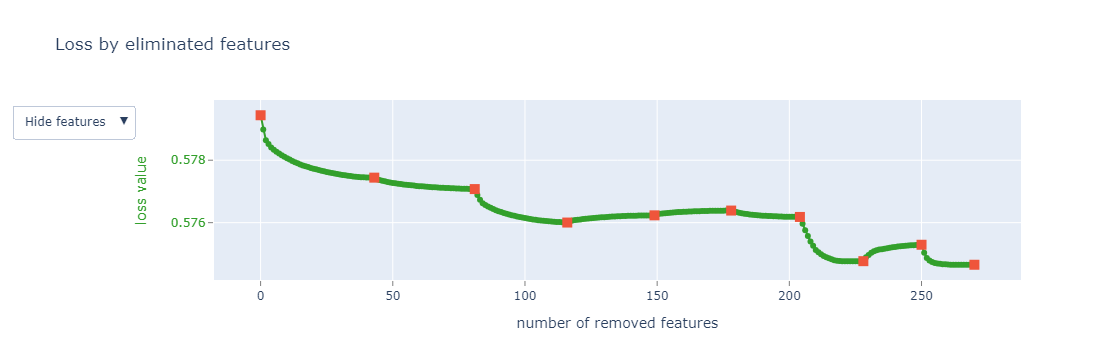

ROC AUC 0.7711935960740666
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


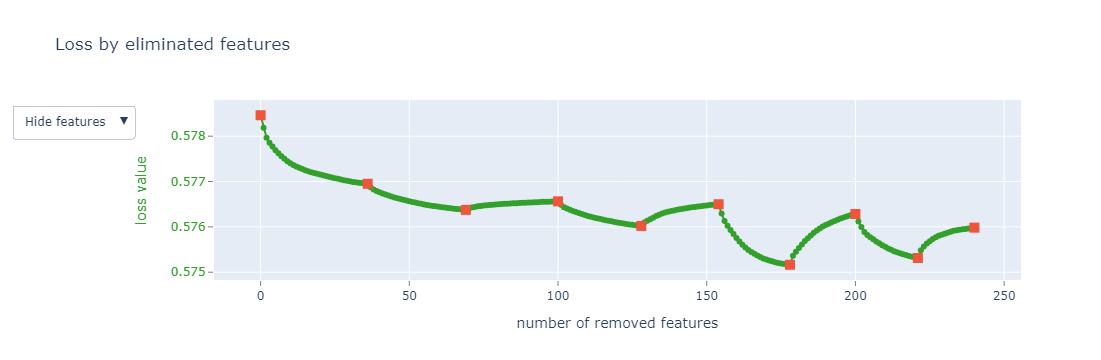

ROC AUC 0.7725005480821743
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


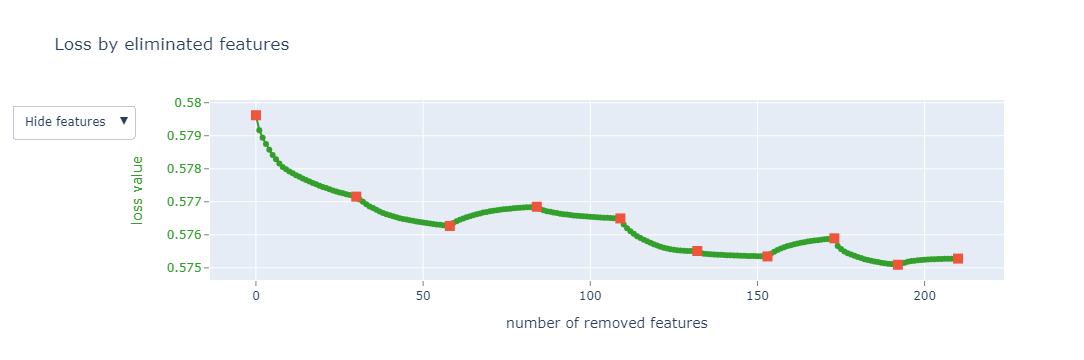

ROC AUC 0.7718548932896272
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


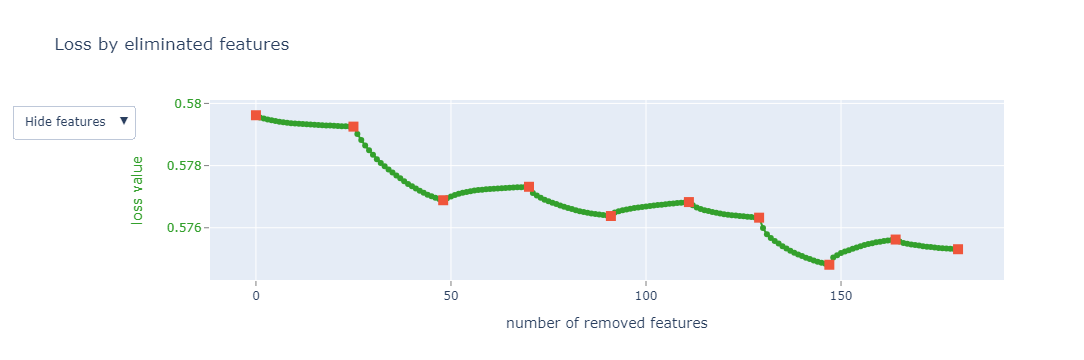

ROC AUC 0.7717881636083846
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


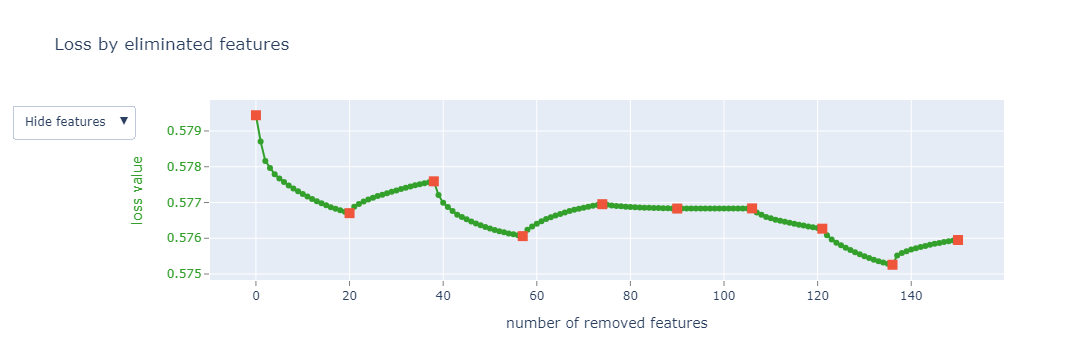

ROC AUC 0.7717090208936594
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


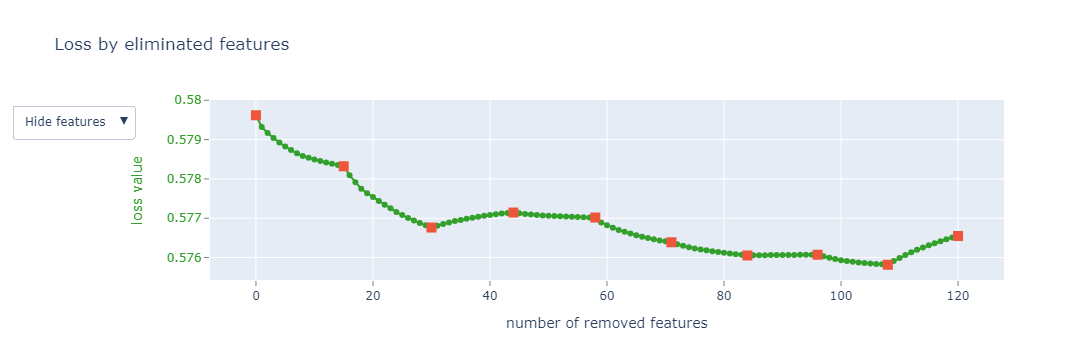

ROC AUC 0.7729601102926273
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


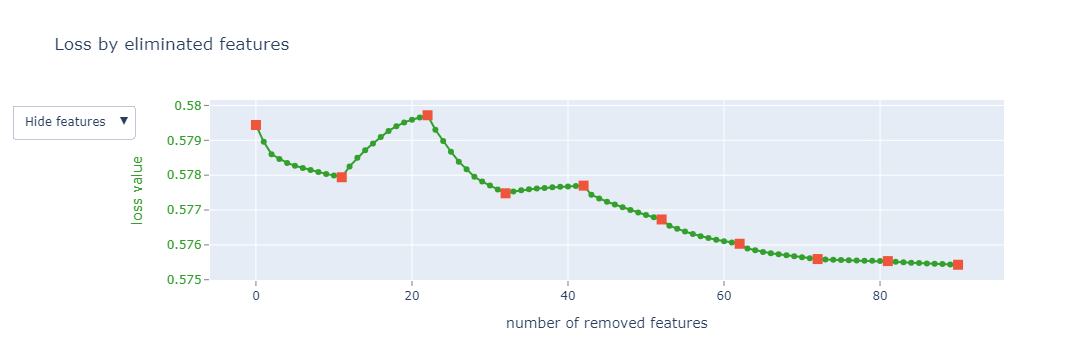

ROC AUC 0.772078312058448
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


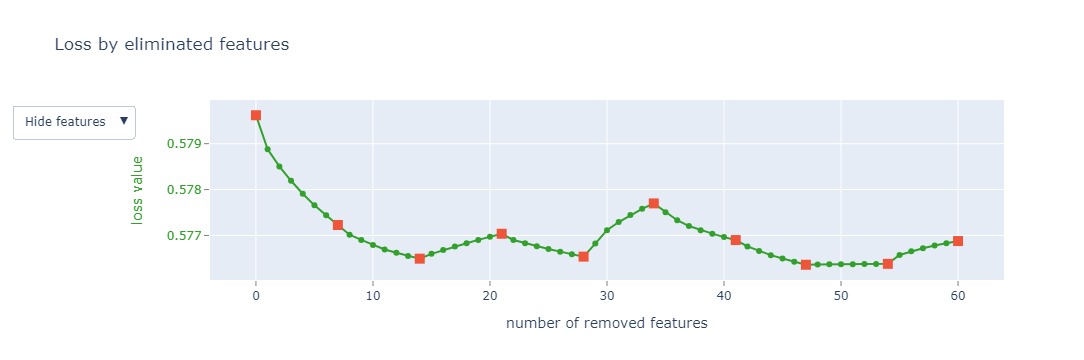

ROC AUC 0.7721935444786849
Algorithm: EFeaturesSelectionAlgorithm.RecursiveByShapValues


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


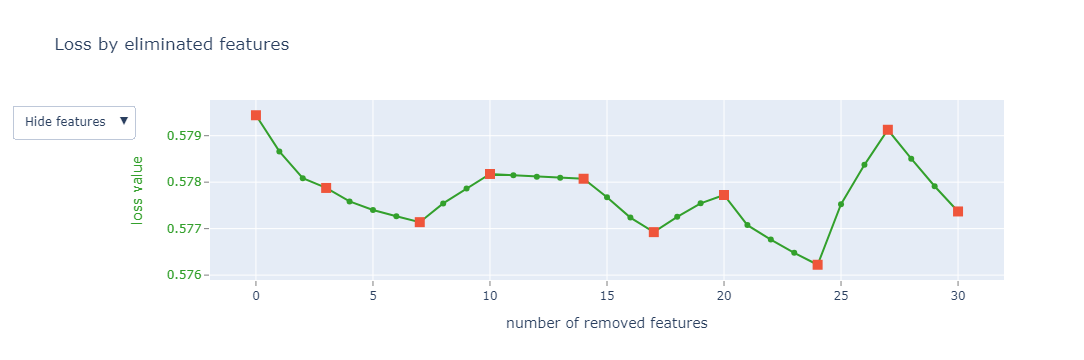

ROC AUC 0.7722635366566386
Best ROC AUC 0.7729601102926273, Count feat 350


In [32]:
best_roc_auc = -1
best_iter = 0

for i in range(200, 467, 30):
    shap_summary, roc_auc_ = select_features_(algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues, steps=9, num_features=i)
    #min_loss, min_removed_features_count = best_remove_feat(shap_summary)
    if roc_auc_ > best_roc_auc:
        best_roc_auc = roc_auc_
        best_iter = i
        best_shap = shap_summary
print(f'Best ROC AUC {best_roc_auc}, Count feat {best_iter}')

In [33]:
selected_features = best_shap['selected_features_names']
selected_features

['rn_x',
 'pre_since_opened',
 'pre_pterm',
 'pre_fterm',
 'pre_till_pclose',
 'pre_till_fclose',
 'pre_loans_next_pay_summ',
 'pre_loans_outstanding',
 'pre_loans_total_overdue',
 'pre_loans_max_overdue_sum',
 'pre_loans_credit_cost_rate',
 'pre_loans5',
 'pre_loans530',
 'pre_loans3060',
 'pre_loans6090',
 'pre_loans90',
 'is_zero_loans530',
 'is_zero_loans3060',
 'is_zero_loans6090',
 'pre_util',
 'pre_over2limit',
 'pre_maxover2limit',
 'is_zero_util',
 'is_zero_over2limit',
 'is_zero_maxover2limit',
 'enc_paym_1',
 'enc_paym_4',
 'enc_paym_6',
 'enc_paym_7',
 'enc_paym_8',
 'enc_paym_9',
 'enc_paym_10',
 'enc_paym_11',
 'enc_paym_12',
 'enc_paym_13',
 'enc_paym_14',
 'enc_paym_15',
 'enc_paym_16',
 'enc_paym_17',
 'enc_paym_18',
 'enc_paym_19',
 'enc_paym_20',
 'enc_paym_21',
 'enc_paym_22',
 'enc_paym_23',
 'enc_paym_24',
 'enc_loans_account_holder_type',
 'enc_loans_credit_status',
 'enc_loans_credit_type',
 'enc_loans_account_cur',
 'pclose_flag',
 'fclose_flag',
 'count_active

In [34]:
model_CB_RFE = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )
model_CB_RFE.fit(
                    train_X[selected_features], train_y,
                    eval_set=(val_X[selected_features], val_y),
                    verbose=False,
                    plot=True
                  )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [35]:
print(f'ROC AUC {roc_auc_score(y_test, model_CB_RFE.predict_proba(X_test[selected_features])[:, 1])}')

ROC AUC 0.771149944976442


### 7.2 SelectKBest

In [36]:
model_CB_Kbest = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )

In [37]:
# Отбор признаков
scores = {}
best_score = -1
best_count_feat = -1
for i in range(290, 467, 30):
    selector = SelectKBest(score_func=mutual_info_classif, k=i)
    X_selected = selector.fit_transform(X, y)

    selected_features_KBest = X.columns[selector.get_support()]

    #cat_features_drop = [item for item in cat_features if item in selected_features]

    model_CB_Kbest.fit(
                            train_X[selected_features_KBest], train_y,
                            eval_set=(val_X[selected_features_KBest], val_y),
                            verbose=False,
                            plot=True
                        )
    print(i, roc_auc_score(y_test, model_CB_Kbest.predict_proba(X_test[selected_features_KBest])[:, 1]))
    scores[i] = roc_auc_score(y_test, model_CB_Kbest.predict_proba(X_test[selected_features_KBest])[:, 1])
    if best_score < roc_auc_score(y_test, model_CB_Kbest.predict_proba(X_test[selected_features_KBest])[:, 1]):
        best_score = roc_auc_score(y_test, model_CB_Kbest.predict_proba(X_test[selected_features_KBest])[:, 1])
        best_count_feat = i
print(f'Best score = {best_score}, count features = {best_count_feat}')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


290 0.767198066804371


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


...

Default metric period is 5 because AUC is/are not implemented for GPU


410 0.7725417931514498


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


440 0.7710862625952382
Best score = 0.7726349344457101, count features = 350


In [38]:
selector = SelectKBest(score_func=mutual_info_classif, k=410)
X_selected = selector.fit_transform(X, y)

selected_features_KBest = X.columns[selector.get_support()]
model_CB_Kbest.fit(
                    train_X[selected_features_KBest], train_y,
                    eval_set=(val_X[selected_features_KBest], val_y),
                    verbose=False,
                    plot=True
                  )
print(roc_auc_score(y_test, model_CB_Kbest.predict_proba(X_test[selected_features_KBest])[:, 1]))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0.7727759883074882


### 7.3 Важность признаков по мнению модели

In [39]:
model_CB_Feat_Imp = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )

In [40]:
model_CB_Feat_Imp.fit(
                    train_X[selected_features], train_y,
                    eval_set=(val_X[selected_features], val_y),
                    verbose=False,
                    plot=True
                  )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [41]:
catboost_importance = model_CB_Feat_Imp.feature_importances_
importances = pd.DataFrame(zip(X_train.columns,
                               catboost_importance), 
                           columns=['feature', 
                                    'imp_catboost'])
importances 

,feature,imp_catboost
0,rn_x,0.067296
1,pre_since_opened,0.648602
2,pre_since_confirmed,0.858994
3,pre_pterm,1.072124
4,pre_fterm,0.197099
...,...,...
345,pre_fterm_9,0.000000
346,pre_till_pclose_2,0.227623
347,fclose_flag_1,0.000000
348,pre_maxover2limit_10,0.024543


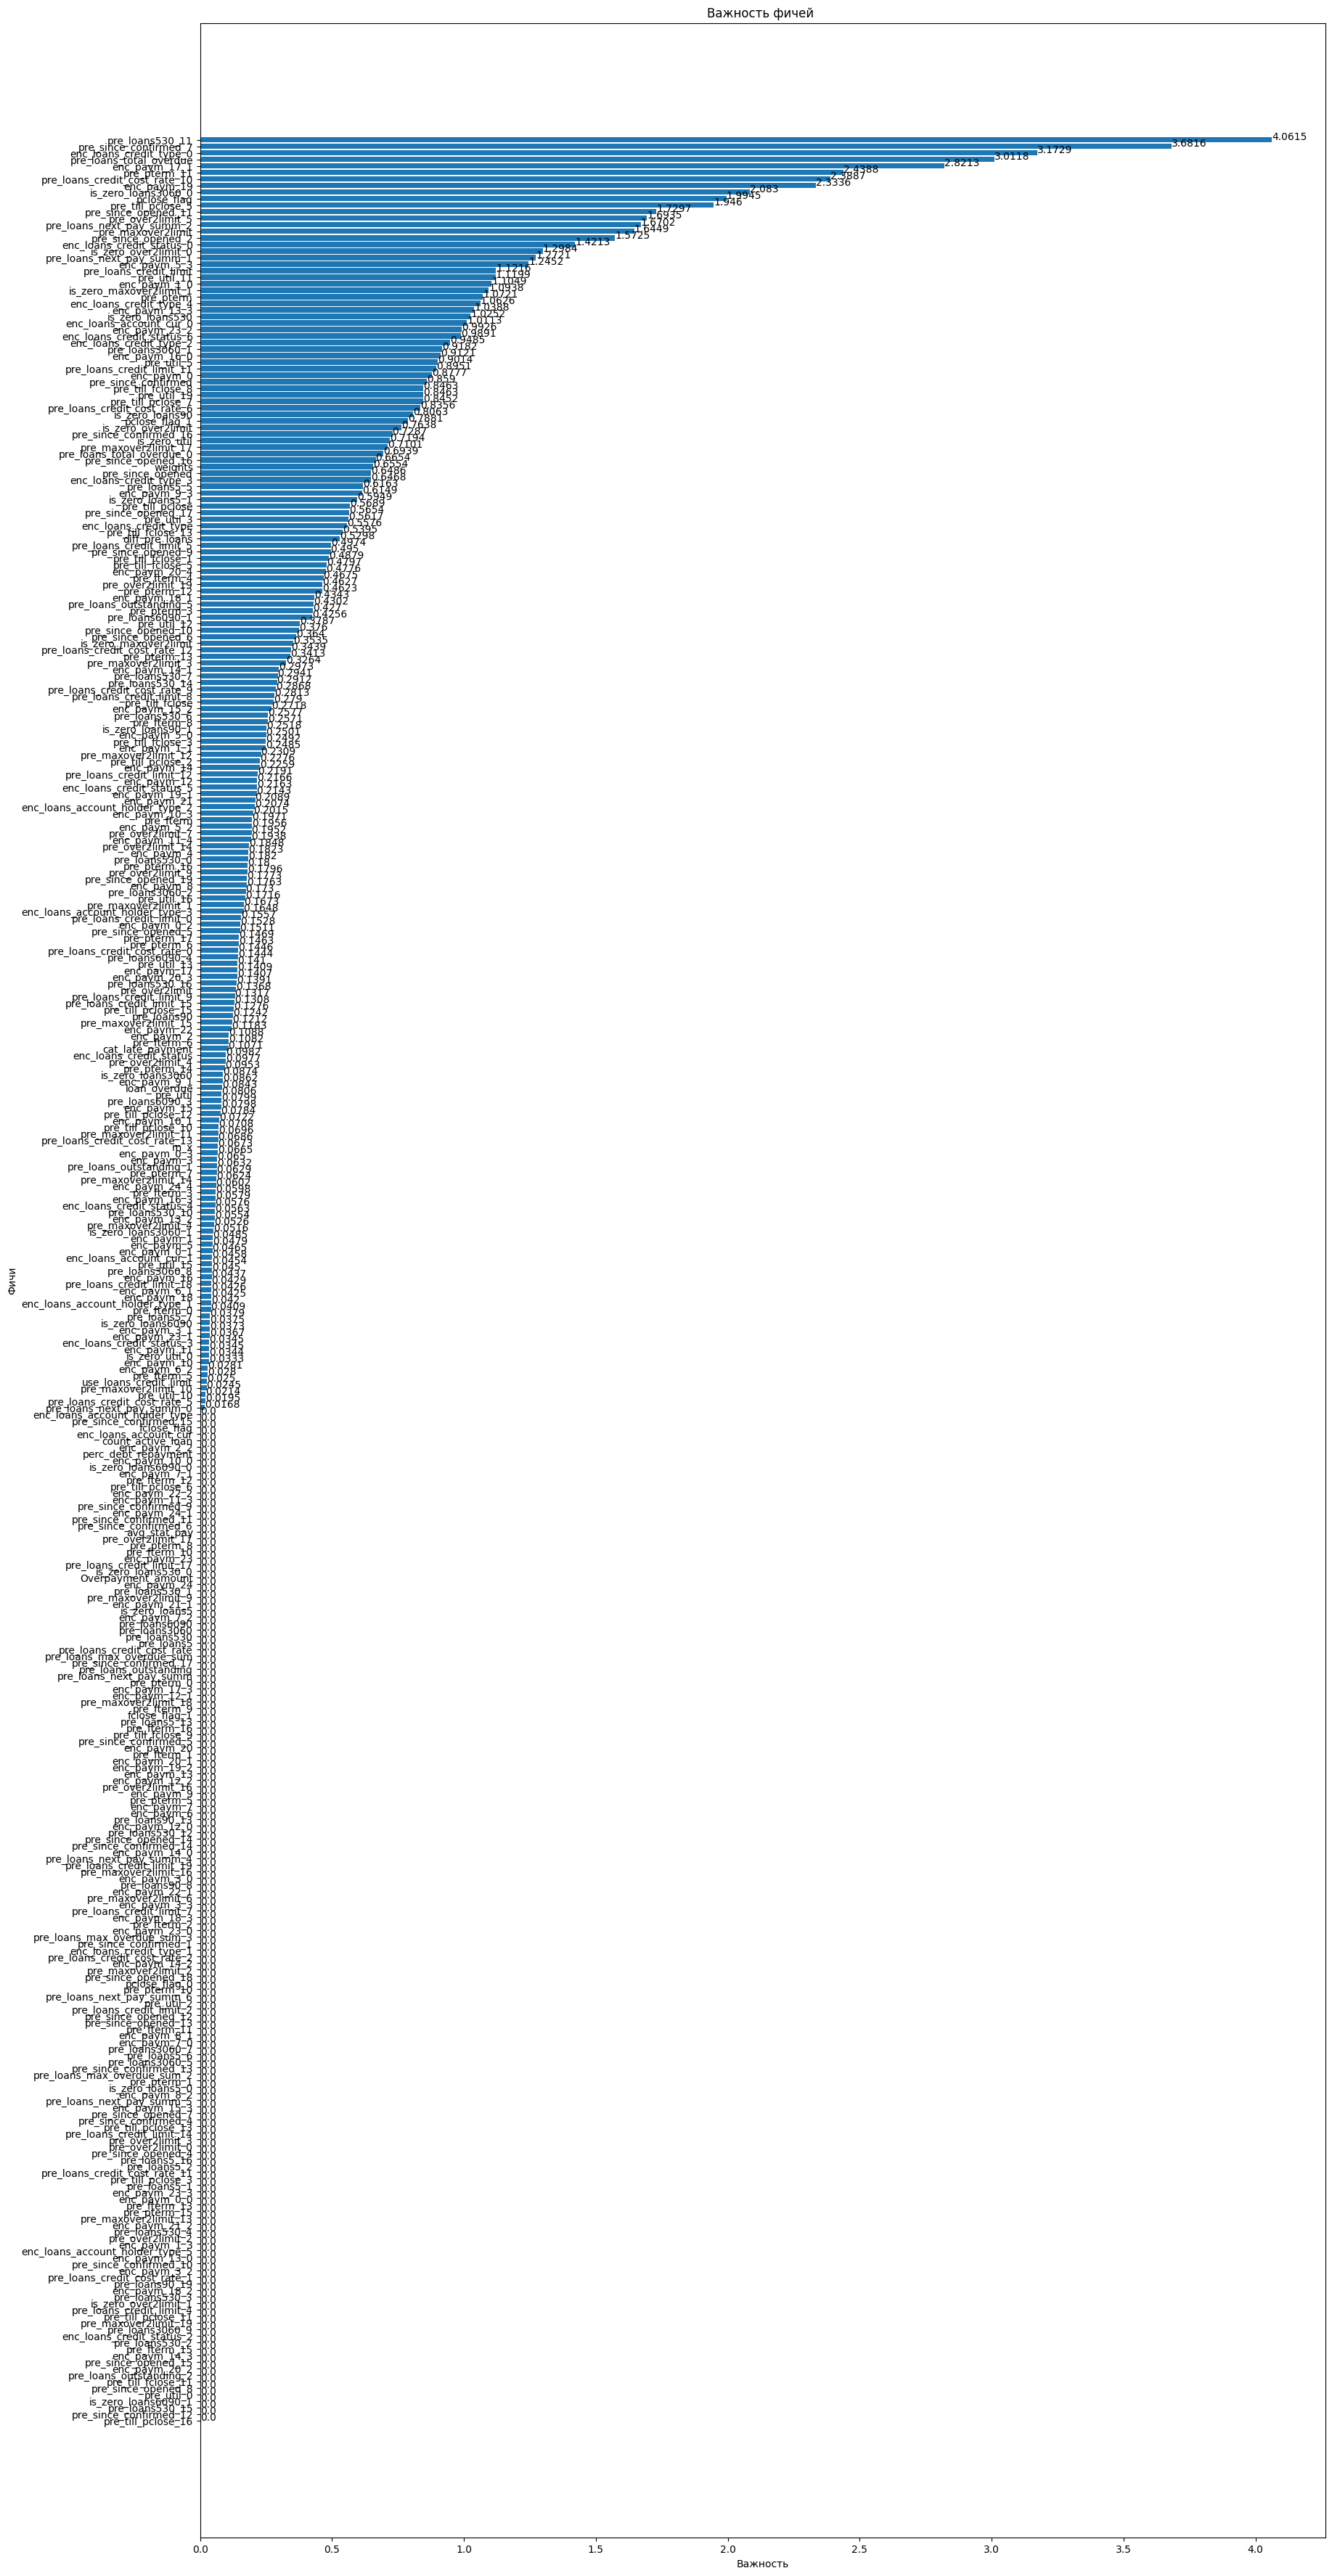

In [42]:
# Создание горизонтальной гистограммы
fig, ax = plt.subplots(figsize=(20, 45))
data_sorted = importances.sort_values('imp_catboost', ascending=True)
# Настройка параметров внешнего вида data_sorted
ax.barh(data_sorted['feature'], data_sorted['imp_catboost'])
ax.set_xlabel('Важность')
ax.set_ylabel('Фичи')
ax.set_title(f'Важность фичей ')

# Добавление числовой информации о важности на гистограмме
for i, v in enumerate(data_sorted['imp_catboost']):
    ax.text(v, i, str(round(v,4)))

plt.show()

In [43]:
#Удаляем все признаки, важность которых равна 0
feature_imp = data_sorted[data_sorted['imp_catboost'] > 0.00].feature.values


In [44]:
model_CB_Feat_Imp = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='Balanced',
                               use_best_model=True
                                       )
model_CB_Feat_Imp.fit(
                            train_X[feature_imp], train_y,
                            eval_set=(val_X[feature_imp], val_y),
                            verbose=False,
                            plot=True
                        )
print(f'ROC AUC {roc_auc_score(y_test, model_CB_Feat_Imp.predict_proba(X_test[feature_imp])[:, 1])}')

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


ROC AUC 0.7611102126749993


* Рекурсивное исключение признаков ROC AUC 0.7719669560572022
* SelectKBest ROC AUC 0.7721733433408757
* Метод feature_importances ROC AUC 0.7580375762870044
#### Не смотря на то, что SelectKBest показал лучший результат, для итоговой модели будем использовать Рекурсивное исключение признаков. Выбранный способ лучше по скорости выполнения, а SelectKBest не справился со всем объемом датасета(необходимо намного больш вычислительной мощности). Разница же по  ROC AUC между ними небольшая

## 8. Балансировка классов целевой переменной

Для балансировки классов целевой переменной будем использовать четеры метода:
  * upsampling
  * downsampling
  * SMOTE
  * Веса классов
  
В итоге выберем тот, что выдает лучший результат ROC AUC

In [45]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Применение upsampling
ros = RandomOverSampler()
X_train_upsampled, y_train_upsampled = ros.fit_resample(train_X[selected_features], train_y)

# Применение downsampling
rus = RandomUnderSampler()
X_train_downsampled, y_train_downsampled = rus.fit_resample(train_X[selected_features], train_y)

# Применение SMOTE
smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(train_X[selected_features], train_y)


In [46]:
model_CatBoost_GPU_UPS = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               use_best_model=True

                                       )
model_CatBoost_GPU_DS = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               use_best_model=True

                                       )
model_CatBoost_GPU_SM = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               use_best_model=True
                                       )
model_CatBoost_GPU_Weight = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               auto_class_weights='SqrtBalanced',
                               use_best_model=True
                                       )

In [47]:
model_CatBoost_GPU_UPS.fit(
                        X_train_upsampled[selected_features], y_train_upsampled,
                        eval_set=(val_X[selected_features], val_y),
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [48]:
model_CatBoost_GPU_DS.fit(
                        X_train_downsampled[selected_features], y_train_downsampled,
                        eval_set=(val_X[selected_features], val_y),
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [49]:
model_CatBoost_GPU_SM.fit(
                        X_train_smote[selected_features], y_train_smote,
                        eval_set=(val_X[selected_features], val_y),
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [50]:
model_CatBoost_GPU_Weight.fit(
                        train_X[selected_features], train_y,
                        eval_set=(val_X[selected_features], val_y),
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [51]:
print(f'ROC AUC Catboost_GPU_UPS = {roc_auc_score(y_test, model_CatBoost_GPU_UPS.predict_proba(X_test)[:, 1])}')
print(f'ROC AUC Catboost_GPU_DS = {roc_auc_score(y_test, model_CatBoost_GPU_DS.predict_proba(X_test)[:, 1])}')
print(f'ROC AUC Catboost_GPU_SM = {roc_auc_score(y_test, model_CatBoost_GPU_SM.predict_proba(X_test)[:, 1])}')
print(f'ROC AUC CatBoost_GPU_Weight = {roc_auc_score(y_test, model_CatBoost_GPU_Weight.predict_proba(X_test)[:, 1])}')

ROC AUC Catboost_GPU_UPS = 0.7716333414778916
ROC AUC Catboost_GPU_DS = 0.7700916674777445
ROC AUC Catboost_GPU_SM = 0.6685191640712173
ROC AUC CatBoost_GPU_Weight = 0.7752908853007435


#### Наилучший результат мы получили с использованием весов классов целевой переменной

## 9. Тюнинг моделей 

Для тюнинга моделей CatBoost применим библиотеку Optuna.
Для моделей из библиотеки sklearn будем использовать метод GridSearch из той же библиотеки.

In [55]:
!pip3 install optuna 


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/413.4 kB ? eta -:--:--
   -- ------------------------------------- 30.7/413.4 kB 1.3 MB/s eta 0:00:01
   ---------- ----------------------------- 112.6/413.4 kB 1.3 MB/s eta 0:00:01
   ------------------- -------------------- 204.8/413.4 kB 1.6 MB/s eta 0:00:01
   ------------------------------- -------- 327.7/413.4 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------  409.6/413.4 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 413.4/413.4 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/233.4 kB ? eta -:--:--
   ---------------------------------------- 233.4/233.4 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -- ------------------------------------- 0.1/2.1 MB 7.0 MB/s eta 0:00:01
   ---------- ----------------------------- 0.5/2.1 MB 5.6 MB/s eta 0:00:01


In [56]:
# Для каждой модели задаем пространство гиперпараметров, которые нужно оптимизировать в GridSearchCV и optuna

In [57]:
import optuna
from optuna.samplers import TPESampler
from catboost.utils import eval_metric

In [59]:
numeric_train_pool = Pool(train_X[selected_features], train_y)
numeric_val_pool = Pool(val_X[selected_features],val_y)
numeric_test_pool = Pool(X_test[selected_features], y_test)

In [62]:
def calc_test_quality(train_pool=numeric_train_pool, val_pool=numeric_val_pool, test_pool=numeric_test_pool, task_type='GPU', **kwargs):
    model = CatBoostClassifier(**kwargs, random_seed=42, 
                               iterations=2000,
                               task_type=task_type,
                               early_stopping_rounds=20)
    model.fit(train_pool, verbose=0, eval_set=val_pool)
    y_pred = model.predict_proba(test_pool)
    return eval_metric(test_pool.get_label(), y_pred[:, 1], 'AUC')

In [63]:
def calc_test_quality_2(train_pool=numeric_train_pool, val_pool=numeric_val_pool, test_pool=numeric_test_pool, **kwargs):
    model = CatBoostClassifier(**kwargs, random_seed=42, 
                               iterations=2000,
                               #task_type='GPU',
                               early_stopping_rounds=20)
    model.fit(train_pool, verbose=0, eval_set=val_pool)
    y_pred = model.predict_proba(test_pool)
    return eval_metric(test_pool.get_label(), y_pred[:, 1], 'AUC')

In [64]:
categorical_features = [item for item in cat_features if item in selected_features]

In [65]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced']),
        
    }

    model = CatBoostClassifier(**params, 
                               random_seed=42, 
                               iterations=2000,
                               task_type='GPU',
                               early_stopping_rounds=20)
    model.fit(numeric_train_pool, verbose=0, eval_set=numeric_val_pool)
    y_pred = model.predict_proba(numeric_val_pool)
    return eval_metric(numeric_val_pool.get_label(), y_pred[:, 1], 'AUC')

sampler = TPESampler(seed=123)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=20)

[I 2023-12-29 15:14:55,313] A new study created in memory with name: no-name-329151b1-2d08-481a-b63a-ea5ea3b9e230
[I 2023-12-29 15:15:06,150] Trial 0 finished with value: 0.771055220207477 and parameters: {'learning_rate': 0.02392938371195723, 'depth': 5, 'l2_leaf_reg': 3.041663082077828, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.771055220207477.
[I 2023-12-29 15:15:13,523] Trial 1 finished with value: 0.7612772678174412 and parameters: {'learning_rate': 0.01846212920248922, 'depth': 10, 'l2_leaf_reg': 7.1634676472637695, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.771055220207477.
[I 2023-12-29 15:15:27,464] Trial 2 finished with value: 0.7709982186340014 and parameters: {'learning_rate': 0.016863560323017387, 'depth': 8, 'l2_leaf_reg': 4.947150202116619, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.771055220207477.
[I 2023-12-29 15:15:36,864] Trial 3 finished with value: 0.7702948579918962 and parameters: {'learn

In [66]:
calc_test_quality(**study.best_params), study.best_params

([0.7765097146313056],
 {'learning_rate': 0.015009107307930133,
  'depth': 6,
  'l2_leaf_reg': 9.870038070496346,
  'auto_class_weights': 'SqrtBalanced'})

In [67]:
model_CB_optuna_GPU = CatBoostClassifier(random_seed=63,
                               task_type='GPU',
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               use_best_model=True,
                               learning_rate=0.011842098798901503,
                               depth=6,
                               l2_leaf_reg=4.877764869966795,
                               auto_class_weights='Balanced'

                                       )
model_CB_optuna_GPU.fit(train_X[selected_features], train_y,
                        eval_set=(val_X[selected_features], val_y),
                        cat_features=categorical_features,
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


In [68]:
def objective_2(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.03),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', 'SqrtBalanced']),
    }

    model = CatBoostClassifier(**params, 
                               random_seed=42, 
                               iterations=2000,
                               #task_type='GPU',
                               early_stopping_rounds=20)
    model.fit(numeric_train_pool, verbose=0, eval_set=numeric_val_pool)
    y_pred = model.predict_proba(numeric_val_pool)
    return eval_metric(numeric_val_pool.get_label(), y_pred[:, 1], 'AUC')

sampler = TPESampler(seed=123)
study2 = optuna.create_study(direction='maximize', sampler=sampler)
study2.optimize(objective_2, n_trials=20)

[I 2023-12-29 15:34:23,292] A new study created in memory with name: no-name-af695f02-1a49-45b9-9a33-c4cb00beb516
[I 2023-12-29 15:35:20,756] Trial 0 finished with value: 0.771147715211115 and parameters: {'learning_rate': 0.02392938371195723, 'depth': 5, 'l2_leaf_reg': 3.041663082077828, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.771147715211115.
[I 2023-12-29 15:36:21,471] Trial 1 finished with value: 0.7641055974754973 and parameters: {'learning_rate': 0.01846212920248922, 'depth': 10, 'l2_leaf_reg': 7.1634676472637695, 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.771147715211115.
[I 2023-12-29 15:37:40,297] Trial 2 finished with value: 0.770474092029926 and parameters: {'learning_rate': 0.016863560323017387, 'depth': 8, 'l2_leaf_reg': 4.947150202116619, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.771147715211115.
[I 2023-12-29 15:39:00,407] Trial 3 finished with value: 0.7714657593163741 and parameters: {'learni

In [69]:
calc_test_quality_2(**study2.best_params), study2.best_params

([0.7760955783512343],
 {'learning_rate': 0.015009107307930133,
  'depth': 6,
  'l2_leaf_reg': 9.870038070496346,
  'auto_class_weights': 'SqrtBalanced'})

In [70]:
model_CB_optuna_CPU = CatBoostClassifier(random_seed=63,
                               early_stopping_rounds=20,
                               eval_metric='AUC:hints=skip_train~false',
                               use_best_model=True,
                               learning_rate=0.013825994516283503,
                               depth=6,
                               l2_leaf_reg=8.045849262672586,
                               auto_class_weights='SqrtBalanced'

                                       )
model_CB_optuna_CPU.fit(train_X[selected_features], train_y,
                        eval_set=(val_X[selected_features], val_y),
                        cat_features=categorical_features,
                        verbose=False,
                        plot=True
                    )

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [71]:
# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_X[selected_features])
X_val_scaled = scaler.fit_transform(val_X[selected_features])
X_test_scaled = scaler.transform(X_test[selected_features])

In [72]:
logreg_params = {
    'C': [0.01, 0.1],
    'penalty': ['l2', 'l1'],
    'max_iter': [1500, 2500,],                      
    'solver': [ 'lbfgs', 'sag'],   
}
logreg = LogisticRegression(class_weight='balanced' ,random_state=63)
# Создаем экземпляр GridSearchCV для каждой модели с соответствующими гиперпараметрами и метрикой roc_auc_score
logreg_grid = GridSearchCV(logreg, logreg_params, scoring="roc_auc", cv=5, verbose=3)

In [73]:
logreg_grid.fit(X_train_scaled, train_y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END C=0.01, max_iter=1500, penalty=l2, solver=lbfgs;, score=0.750 total time=  26.5s
[CV 2/5] END C=0.01, max_iter=1500, penalty=l2, solver=lbfgs;, score=0.757 total time=  26.7s
[CV 3/5] END C=0.01, max_iter=1500, penalty=l2, solver=lbfgs;, score=0.754 total time=  24.0s
[CV 4/5] END C=0.01, max_iter=1500, penalty=l2, solver=lbfgs;, score=0.751 total time=  27.4s
[CV 5/5] END C=0.01, max_iter=1500, penalty=l2, solver=lbfgs;, score=0.752 total time=  26.8s
[CV 1/5] END C=0.01, max_iter=1500, penalty=l2, solver=sag;, score=0.750 total time=18.8min
[CV 2/5] END C=0.01, max_iter=1500, penalty=l2, solver=sag;, score=0.757 total time=18.1min
[CV 3/5] END C=0.01, max_iter=1500, penalty=l2, solver=sag;, score=0.754 total time=18.6min
[CV 4/5] END C=0.01, max_iter=1500, penalty=l2, solver=sag;, score=0.751 total time=17.9min
[CV 5/5] END C=0.01, max_iter=1500, penalty=l2, solver=sag;, score=0.752 total time=19.0min
[CV 1/5] 

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          random_state=63),
             param_grid={'C': [0.01, 0.1], 'max_iter': [1500, 2500],
                         'penalty': ['l2', 'l1'], 'solver': ['lbfgs', 'sag']},
             scoring='roc_auc', verbose=3)

In [74]:
logreg_grid.best_estimator_

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1500,
                   random_state=63)

In [75]:
%%time

logreg = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1500,
                   random_state=63)
logreg.fit(X_train_scaled, train_y)

CPU times: total: 20min 47s
Wall time: 1min 1s


LogisticRegression(C=0.1, class_weight='balanced', max_iter=1500,
                   random_state=63)

In [76]:
rf_params = {
    'n_estimators': [100, 150], 
    'max_features': ['sqrt', 'log2'], 
    'max_depth': [ 6, 9], 
    'max_leaf_nodes': [6, 9], 
    'class_weight': ['balanced', 'balanced_subsample']
} 

rfc = RandomForestClassifier(random_state=63)
rf_grid = GridSearchCV(rfc, rf_params, scoring="roc_auc", cv=5, verbose=3)

In [77]:

rf_grid.fit(X_train_scaled, train_y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=100;, score=0.707 total time=  43.1s
[CV 2/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=100;, score=0.717 total time=  42.5s
[CV 3/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=100;, score=0.722 total time=  43.1s
[CV 4/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=100;, score=0.718 total time=  42.3s
[CV 5/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=100;, score=0.707 total time=  42.4s
[CV 1/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=150;, score=0.709 total time= 1.1min
[CV 2/5] END class_weight=balanced, max_depth=6, max_features=sqrt, max_leaf_nodes=6, n_estimators=150;, score=0.718 total

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=63),
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [6, 9], 'max_features': ['sqrt', 'log2'],
                         'max_leaf_nodes': [6, 9], 'n_estimators': [100, 150]},
             scoring='roc_auc', verbose=3)

In [78]:
print(rf_grid.best_estimator_)

RandomForestClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=9,
                       n_estimators=150, random_state=63)


In [79]:
%%time

rfc = RandomForestClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=9,
                       n_estimators=150, random_state=63)
rfc.fit(X_train_scaled, train_y)

CPU times: total: 37.8 s
Wall time: 37.8 s


RandomForestClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=9,
                       n_estimators=150, random_state=63)

In [80]:
mlp_params = {
    'solver': ['lbfgs', 'sgd'],
    'hidden_layer_sizes': [(100,), (50,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01]
}
mlp = MLPClassifier(early_stopping=True, max_iter=2000, random_state=63)
mlp_grid = GridSearchCV(mlp, mlp_params, scoring="roc_auc", cv=5, verbose=3)

In [81]:
mlp_grid.fit(X_train_scaled, train_y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=lbfgs;, score=0.597 total time=26.2min
[CV 2/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=lbfgs;, score=0.595 total time=26.5min
[CV 3/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=lbfgs;, score=0.600 total time=29.6min
[CV 4/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=lbfgs;, score=0.594 total time=27.9min
[CV 5/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=lbfgs;, score=0.597 total time=25.1min
[CV 1/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=sgd;, score=0.729 total time= 6.1min
[CV 2/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=sgd;, score=0.728 total time= 6.1min
[CV 3/5] END activation=relu, alpha=0.001, hidden_layer_sizes=(100,), solver=sgd;, score=0.736 total time= 4.1min
[CV 4/5] END acti

GridSearchCV(cv=5,
             estimator=MLPClassifier(early_stopping=True, max_iter=2000,
                                     random_state=63),
             param_grid={'activation': ['relu', 'tanh'], 'alpha': [0.001, 0.01],
                         'hidden_layer_sizes': [(100,), (50, 50)],
                         'solver': ['lbfgs', 'sgd']},
             scoring='roc_auc', verbose=3)

In [82]:
print(mlp_grid.best_estimator_)

MLPClassifier(activation='tanh', alpha=0.01, early_stopping=True, max_iter=2000,
              random_state=63, solver='sgd')


In [83]:
%%time
mlp = MLPClassifier(activation='tanh', alpha=0.001, early_stopping=True,
              max_iter=2000, random_state=63, solver='sgd')
mlp.fit(X_train_scaled, train_y)

CPU times: total: 9min 57s
Wall time: 6min 12s


MLPClassifier(activation='tanh', alpha=0.001, early_stopping=True,
              max_iter=2000, random_state=63, solver='sgd')

In [84]:
print(f'ROC AUC Catboost_GPU = {roc_auc_score(y_test, model_CB_optuna_GPU.predict_proba(X_test[selected_features])[:, 1])}')
print(f'ROC AUC Catboost_СPU = {roc_auc_score(y_test, model_CB_optuna_CPU.predict_proba(X_test[selected_features])[:, 1])}')

print(f'ROC AUC Logreg = {roc_auc_score(y_test, logreg.predict_proba(X_test_scaled)[:, 1])}')
print(f'ROC AUC RandomForest = {roc_auc_score(y_test, rfc.predict_proba(X_test_scaled)[:, 1])}')
print(f'ROC AUC MLP = {roc_auc_score(y_test, mlp.predict_proba(X_test_scaled)[:, 1])}')

ROC AUC Catboost_GPU = 0.7746625081380327
ROC AUC Catboost_СPU = 0.7734956880287015
ROC AUC Logreg = 0.7597324566432972
ROC AUC RandomForest = 0.7260632818649299
ROC AUC MLP = 0.7459658706368537


## 10. Голосование

В голосовании будем использовать три лучших модели: 
* CatBoost на GPU
* CatBoost на GPU
* Логистическая регрессия

Посчитаем средние вероятности, который предсказали эти модели и вычислим ROC AUC на тестовом датасете

In [85]:
logreg_pred = logreg.predict_proba(X_test_scaled)
rfc_pred = rfc.predict_proba(X_test_scaled)
mlp_pred = mlp.predict_proba(X_test_scaled)
catboost_GPU_pred = model_CB_optuna_GPU.predict_proba(X_test[selected_features])
catboost_CPU_pred = model_CB_optuna_CPU.predict_proba(X_test[selected_features])


In [86]:
avg_pred = (catboost_GPU_pred + catboost_CPU_pred + logreg_pred) / 3


In [87]:
print(f'ROC AUC = {roc_auc_score(y_test, avg_pred[:, 1])}')

ROC AUC = 0.7756486285370676


## 11. Определяем порог принятия решения

### 11.1 Определяем порог с помощью иснструментов CatBoost

In [88]:
t = pd.DataFrame({'y_true': y_test, 
                  'y_score': avg_pred[:, 1]})

In [89]:
from catboost.utils import get_roc_curve, select_threshold

pool = Pool(train_X[selected_features], train_y, cat_features=categorical_features)
roc_curve_values = get_roc_curve(model_CB_optuna_GPU, pool)

boundary = select_threshold(model_CB_optuna_GPU, curve=roc_curve_values,  
                            FNR=0.01)
print(boundary)


0.16076128115100907


In [90]:
#Строим ROC кривую, вычисляем множество пороговых значений

In [91]:
(fpr, tpr, thresholds) = roc_curve(t.y_true, t.y_score)

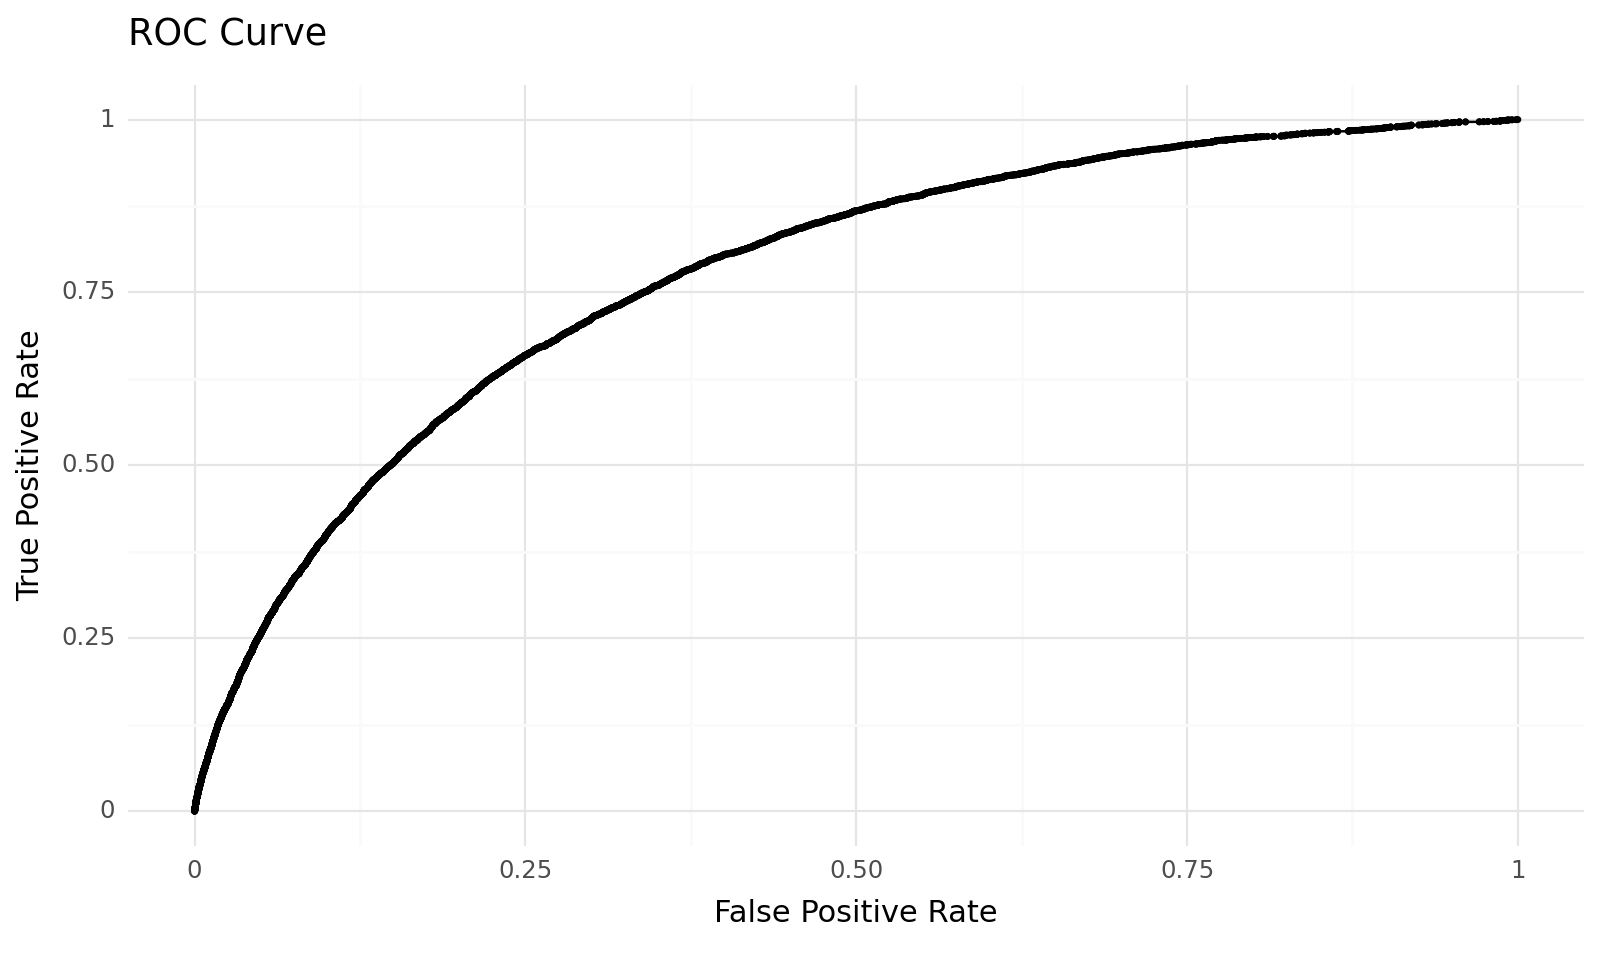

<Figure Size: (800 x 480)>

In [92]:
# Строим кривую ROC
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds})
df_fpr_tpr.head()

# Строим график
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate')+
    ylab('True Positive Rate')+
    theme_minimal()
)

### 11.2 Среднее значение

In [93]:
# Вычисляем G-mean
gmean = np.sqrt(tpr * (1 - fpr))

# Ищем оптимальный threshold
index = np.argmax(gmean)
thr_gmean = round(thresholds[index], ndigits = 4)
gmeanOpt = round(gmean[index], ndigits = 4)
fprOpt = round(fpr[index], ndigits = 4)
tprOpt = round(tpr[index], ndigits = 4)
print('Best Threshold: {} with G-Mean: {}'.format(thr_gmean, gmeanOpt))
print('FPR: {}, TPR: {}'.format(fprOpt, tprOpt))

Best Threshold: 0.3848 with G-Mean: 0.707
FPR: 0.302, TPR: 0.7161


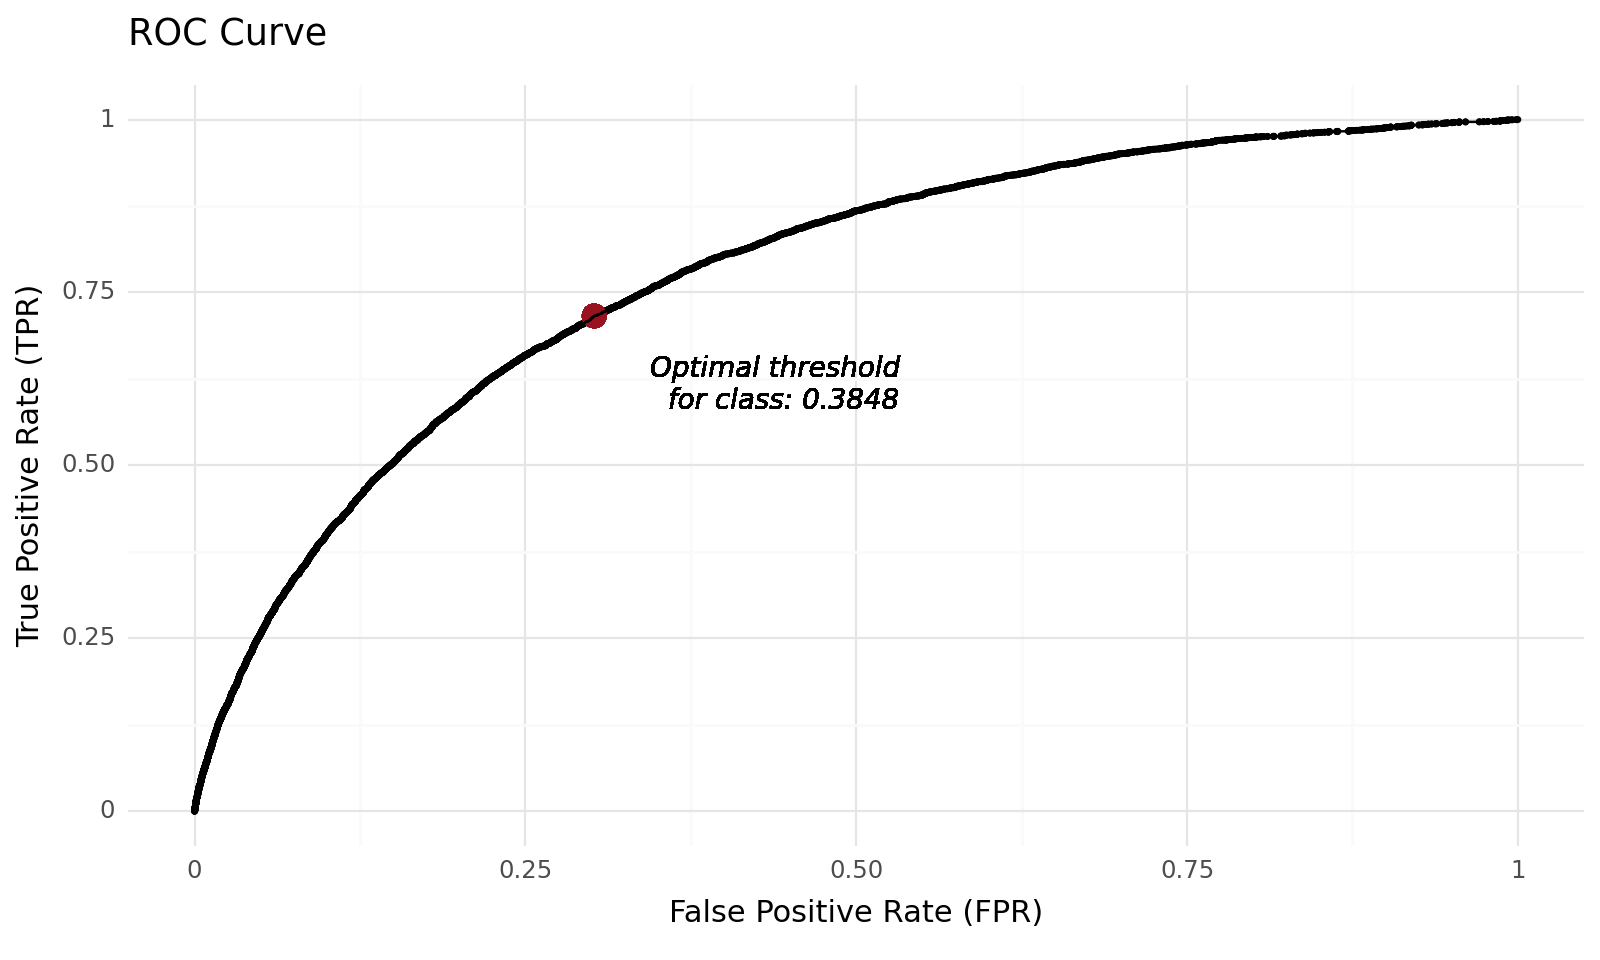

<Figure Size: (800 x 480)>

In [94]:
# Строим график
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    # Лучший threshold
    geom_point(aes(x = fprOpt,
                   y = tprOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    geom_text(aes(x = fprOpt,
                  y = tprOpt),
              label = 'Optimal threshold \n for class: {}'.format(thr_gmean),
              nudge_x = 0.14,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate (FPR)')+
    ylab('True Positive Rate (TPR)')+
    theme_minimal()
)

### 11.3 Статистика Юдена J

In [95]:
# Вычисляем статистику Youden's J 
youdenJ = tpr - fpr

# Ищем оптимальный threshold
index = np.argmax(youdenJ)
thr_youdenJ = round(thresholds[index], ndigits = 4)
youdenJOpt = round(gmean[index], ndigits = 4)
fprOpt = round(fpr[index], ndigits = 4)
tprOpt = round(tpr[index], ndigits = 4)
print('Best Threshold: {} with Youden J statistic: {}'.format(thr_youdenJ, youdenJOpt))
print('FPR: {}, TPR: {}'.format(fprOpt, tprOpt))

Best Threshold: 0.3848 with Youden J statistic: 0.707
FPR: 0.302, TPR: 0.7161


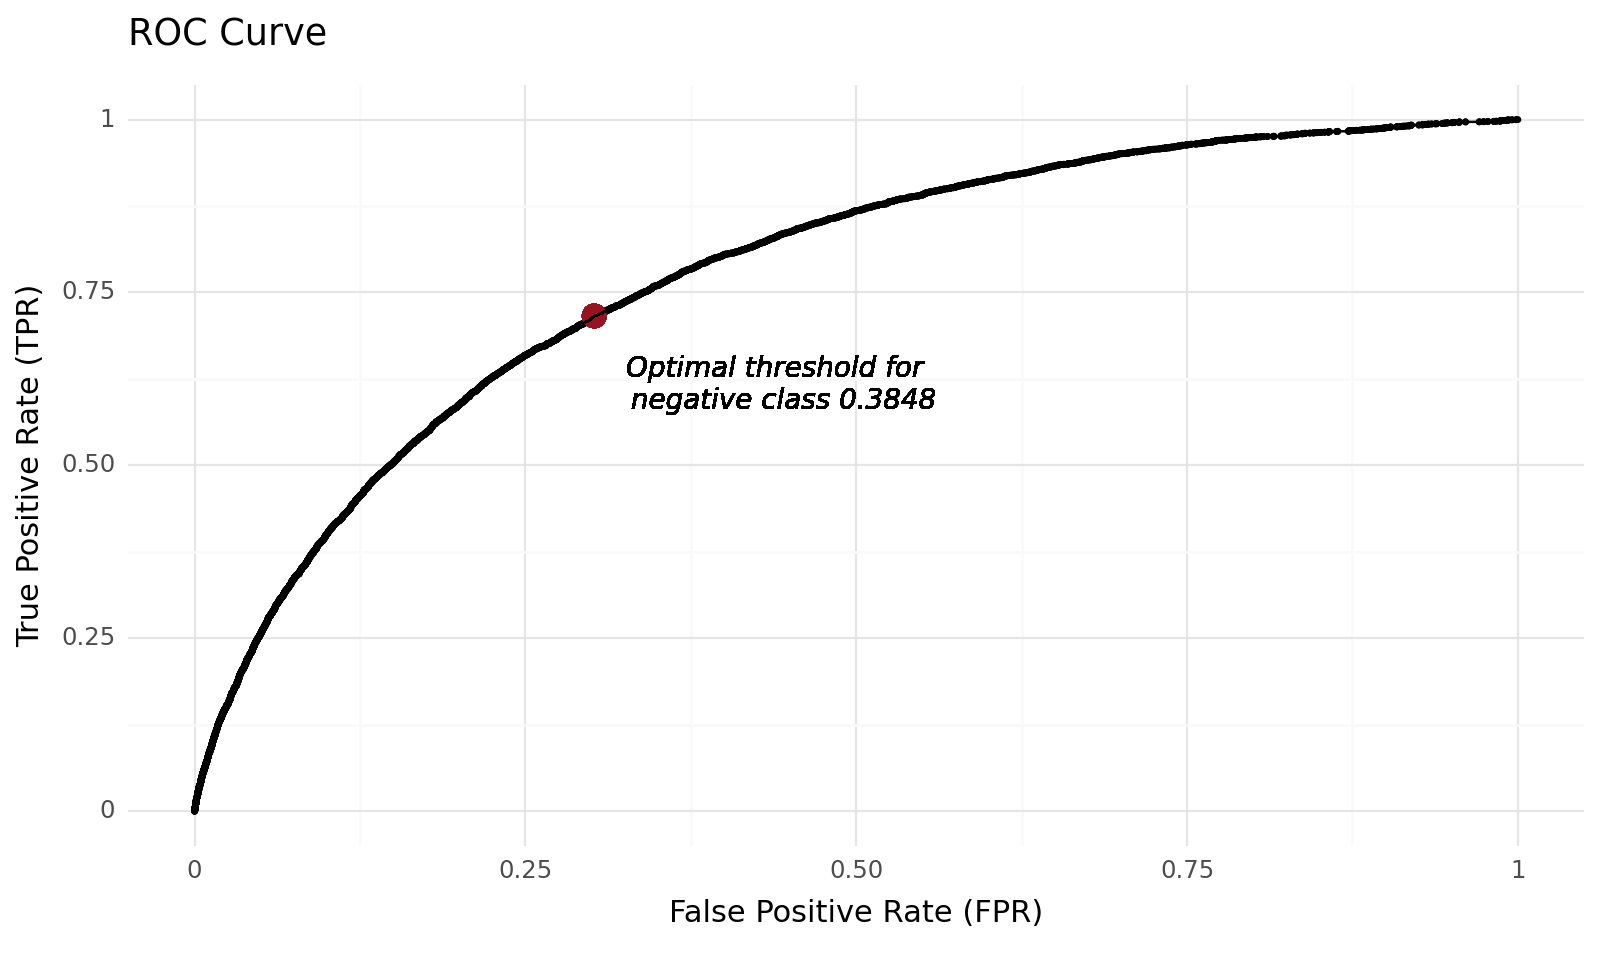

<Figure Size: (800 x 480)>

In [96]:
# Строим график
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    # Лучший threshold
    geom_point(aes(x = fprOpt,
                   y = tprOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    # Ставим надписи
    geom_text(aes(x = fprOpt,
                  y = tprOpt),
              label = 'Optimal threshold for \n negative class {}'.format(thr_youdenJ),
              nudge_x = 0.14,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'ROC Curve')+
    xlab('False Positive Rate (FPR)')+
    ylab('True Positive Rate (TPR)')+
    theme_minimal()
)

### 11.4 Кривая точности-отзыва для поиска оптимального порога

In [97]:
# Строим Precision-Recall кривую
precision, recall, thresholds = precision_recall_curve(t.y_true, t.y_score)

# Строим график
df_recall_precision = pd.DataFrame({'Precision':precision[:-1],
                                    'Recall':recall[:-1],
                                    'Threshold':thresholds})
df_recall_precision.head()


,Precision,Recall,Threshold
0,0.031893,1.0,0.010841
1,0.031894,1.0,0.014828
2,0.031894,1.0,0.016294
3,0.031894,1.0,0.016622
4,0.031894,1.0,0.016849


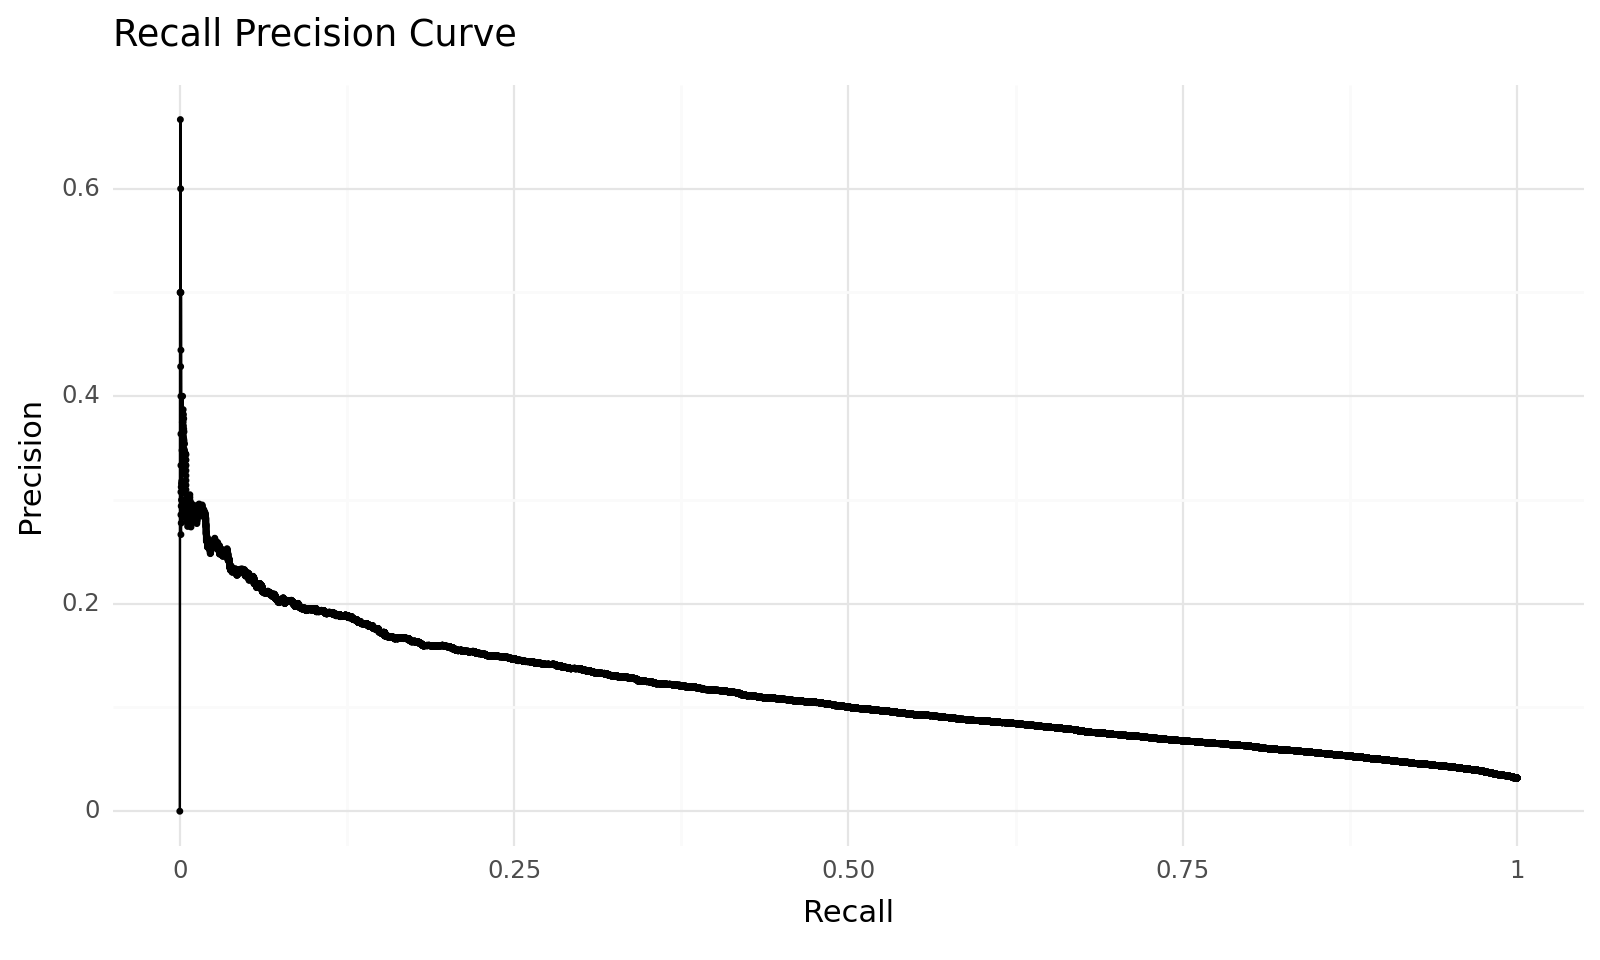

<Figure Size: (800 x 480)>

In [98]:
# Строим график
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_recall_precision)+
    geom_point(aes(x = 'Recall',
                   y = 'Precision'),
               size = 0.4)+
    geom_line(aes(x = 'Recall',
                  y = 'Precision'))+
    labs(title = 'Recall Precision Curve')+
    xlab('Recall')+
    ylab('Precision')+
    theme_minimal()
)

In [99]:
# Вычисляем f-score
fscore = (2 * precision * recall) / (precision + recall)

# Ищем threshold
index = np.argmax(fscore)
thr_pr_curve = round(thresholds[index], ndigits = 4)
fscoreOpt = round(fscore[index], ndigits = 4)
recallOpt = round(recall[index], ndigits = 4)
precisionOpt = round(precision[index], ndigits = 4)
print('Best Threshold: {} with F-Score: {}'.format(thr_pr_curve, fscoreOpt))
print('Recall: {}, Precision: {}'.format(recallOpt, precisionOpt))


Best Threshold: 0.9229 with F-Score: nan
Recall: 0.0, Precision: 0.0


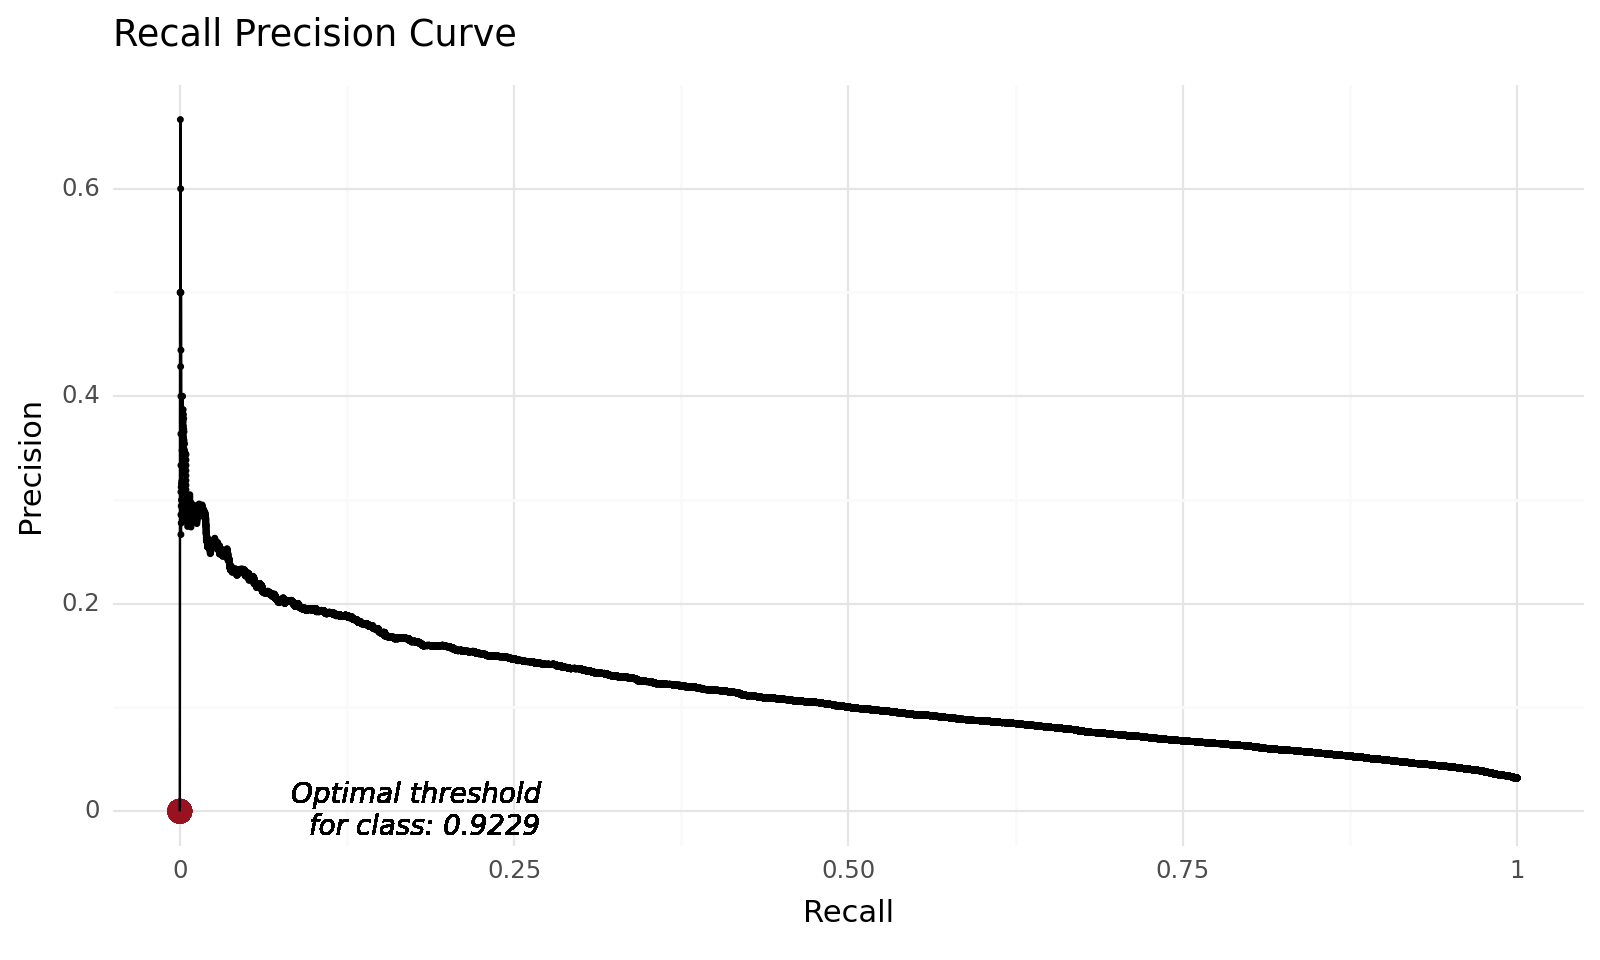

<Figure Size: (800 x 480)>

In [100]:
# Строим график
plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_recall_precision)+
    geom_point(aes(x = 'Recall',
                   y = 'Precision'),
               size = 0.4)+
    # Лучший threshold
    geom_point(aes(x = recallOpt,
                   y = precisionOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'Recall',
                  y = 'Precision'))+
    # Делаем надписи
    geom_text(aes(x = recallOpt,
                  y = precisionOpt),
              label = 'Optimal threshold \n for class: {}'.format(thr_pr_curve),
              nudge_x = 0.18,
              nudge_y = 0,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'Recall Precision Curve')+
    xlab('Recall')+
    ylab('Precision')+
    theme_minimal()
)

### 11.5 Настройка порога

In [101]:
# Массив для нахождения оптимального порога
thresholds = np.arange(0.0, 1.0, 0.0001)
fscore = np.zeros(shape=(len(thresholds)))
print('Length of sequence: {}'.format(len(thresholds)))

# Вычисляем thresholds
for index, elem in enumerate(thresholds):
    # Корректируем вероятности
    y_pred_prob = (t.y_score > elem).astype('int')
    # Вычисляем f-score
    fscore[index] = f1_score(t.y_true, y_pred_prob)
    #print(index, elem)

# Поиск оптимального threshold
index = np.argmax(fscore)
thr_tune = round(thresholds[index], ndigits = 4)
fscoreOpt = round(fscore[index], ndigits = 4)
print('Best Threshold: {} with F-Score: {}'.format(thr_tune, fscoreOpt))

# Данные для графика threshold tuning
df_threshold_tuning = pd.DataFrame({'F-score':fscore,
                                    'Threshold':thr_tune})
df_threshold_tuning.head()

Length of sequence: 10000
Best Threshold: 0.5894 with F-Score: 0.1883


,F-score,Threshold
0,0.061815,0.5894
1,0.061815,0.5894
2,0.061815,0.5894
3,0.061815,0.5894
4,0.061815,0.5894


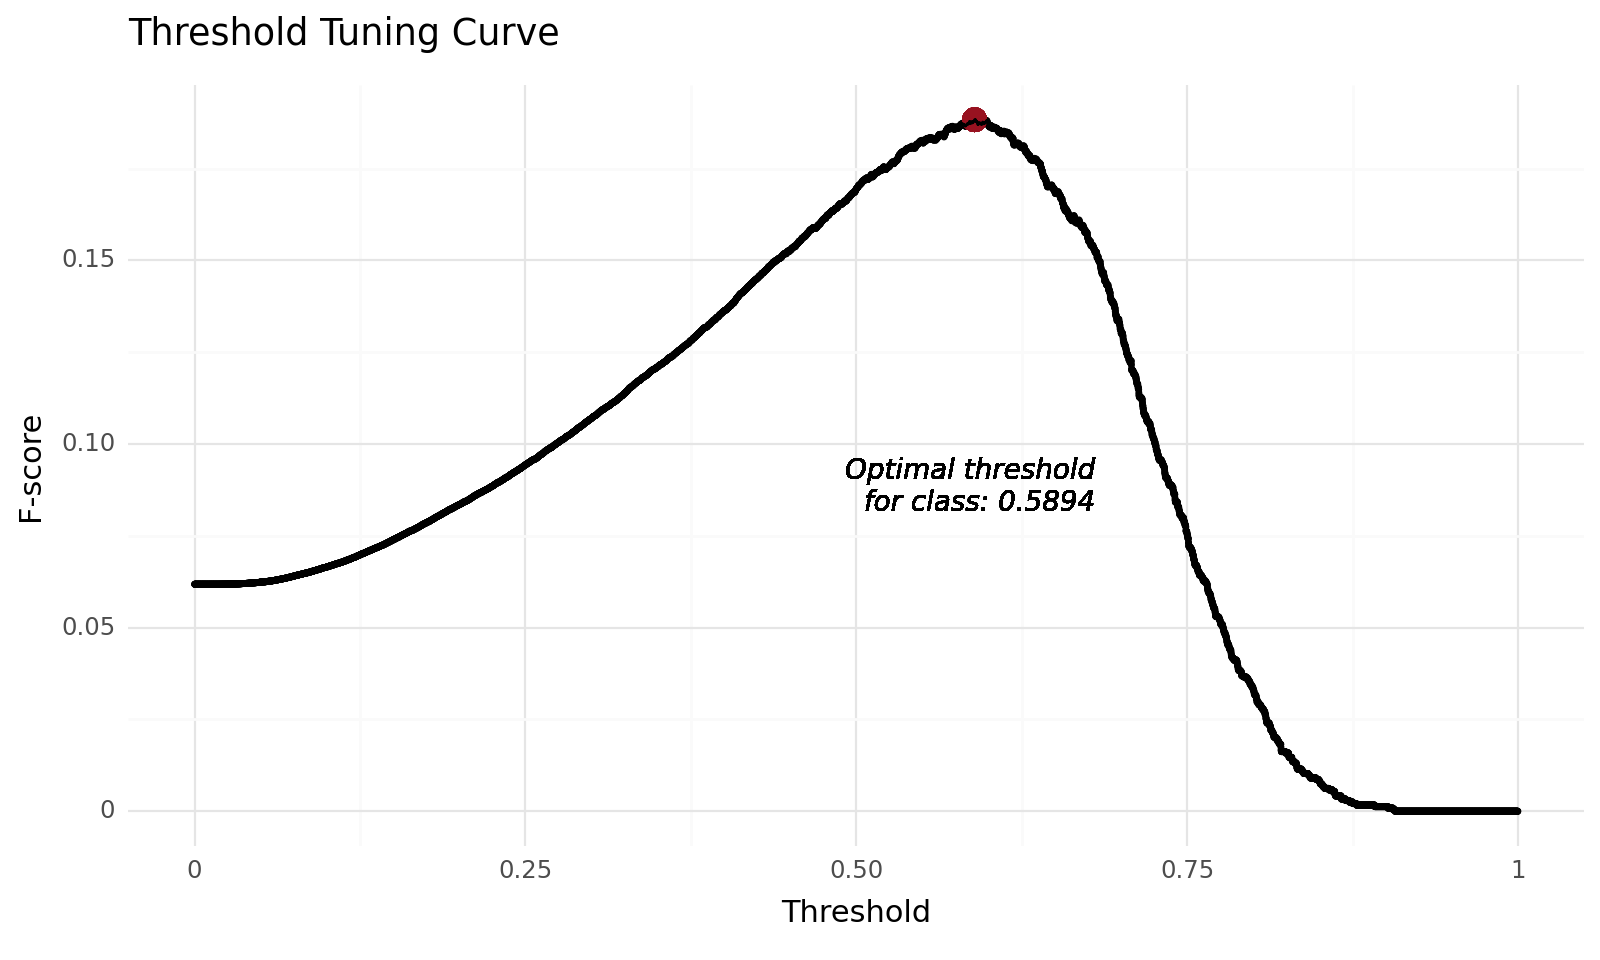

<Figure Size: (800 x 480)>

In [102]:
# Строим график threshold tuning
df_threshold_tuning = pd.DataFrame({'F-score':fscore,
                                    'Threshold':thresholds})
df_threshold_tuning.head()

plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_threshold_tuning)+
    geom_point(aes(x = 'Threshold',
                   y = 'F-score'),
               size = 0.4)+
    # Лучший threshold
    geom_point(aes(x = thr_tune,
                   y = fscoreOpt),
               color = '#981220',
               size = 4)+
    geom_line(aes(x = 'Threshold',
                   y = 'F-score'))+
    # Делаем надписи
    geom_text(aes(x = thr_tune,
                  y = fscoreOpt),
              label = 'Optimal threshold \n for class: {}'.format(thr_tune),
              nudge_x = 0,
              nudge_y = -0.10,
              size = 10,
              fontstyle = 'italic')+
    labs(title = 'Threshold Tuning Curve')+
    xlab('Threshold')+
    ylab('F-score')+
    theme_minimal()
)

In [103]:
print(f'select_threshold boundary  {boundary}')
print(f'thr_tune {thr_tune}')
print(f'thr_pr_curve {thr_pr_curve}')
print(f'thr_youdenJ {thr_youdenJ}')
print(f'thr_gmean {thr_gmean}')

select_threshold boundary  0.16076128115100907
thr_tune 0.5894
thr_pr_curve 0.9229
thr_youdenJ 0.3848
thr_gmean 0.3848


In [104]:
t['y_pred_thr_select_threshold'] = (t['y_score'] >= boundary) * 1
t['y_pred_thr_tune'] = (t['y_score'] >= thr_tune) * 1
t['y_pred_thr_pr_curve'] = (t['y_score'] >= thr_pr_curve) * 1
t['y_pred_thr_youdenJ'] = (t['y_score'] >= thr_youdenJ) * 1
t['y_pred_thr_gmean'] = (t['y_score'] >= thr_gmean) * 1
t

,y_true,y_score,y_pred_thr_select_threshold,y_pred_thr_tune,y_pred_thr_pr_curve,y_pred_thr_youdenJ,y_pred_thr_gmean
92365,0,0.679935,1,1,0,1,1
489241,1,0.423926,1,0,0,1,1
2782,0,0.115110,0,0,0,0,0
102878,0,0.084883,0,0,0,0,0
291247,0,0.488026,1,0,0,1,1
...,...,...,...,...,...,...,...
261844,0,0.273272,1,0,0,0,0
259851,0,0.172484,1,0,0,0,0
37586,0,0.281971,1,0,0,0,0
282701,0,0.202673,1,0,0,0,0


### 11.6 Вывод матрицы ошибок

In [105]:
def view_conf_matrix(cf_matrix):   
    group_names = ['True Neg','False Pos','False Neg','True Pos']

    group_counts = ["{0:0.0f}".format(value) for value in
                    cf_matrix.flatten()]

    group_percentages = ["{0:.2%}".format(value) for value in
                         cf_matrix.flatten()/np.sum(cf_matrix)]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
              zip(group_names,group_counts,group_percentages)]

    labels = np.asarray(labels).reshape(2,2)

    ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')

    ax.set_title('Seaborn Confusion Matrix with labels\n\n');
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ');

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(['False','True'])
    ax.yaxis.set_ticklabels(['False','True'])

    ## Display the visualization of the Confusion Matrix.
    plt.show()
    
    

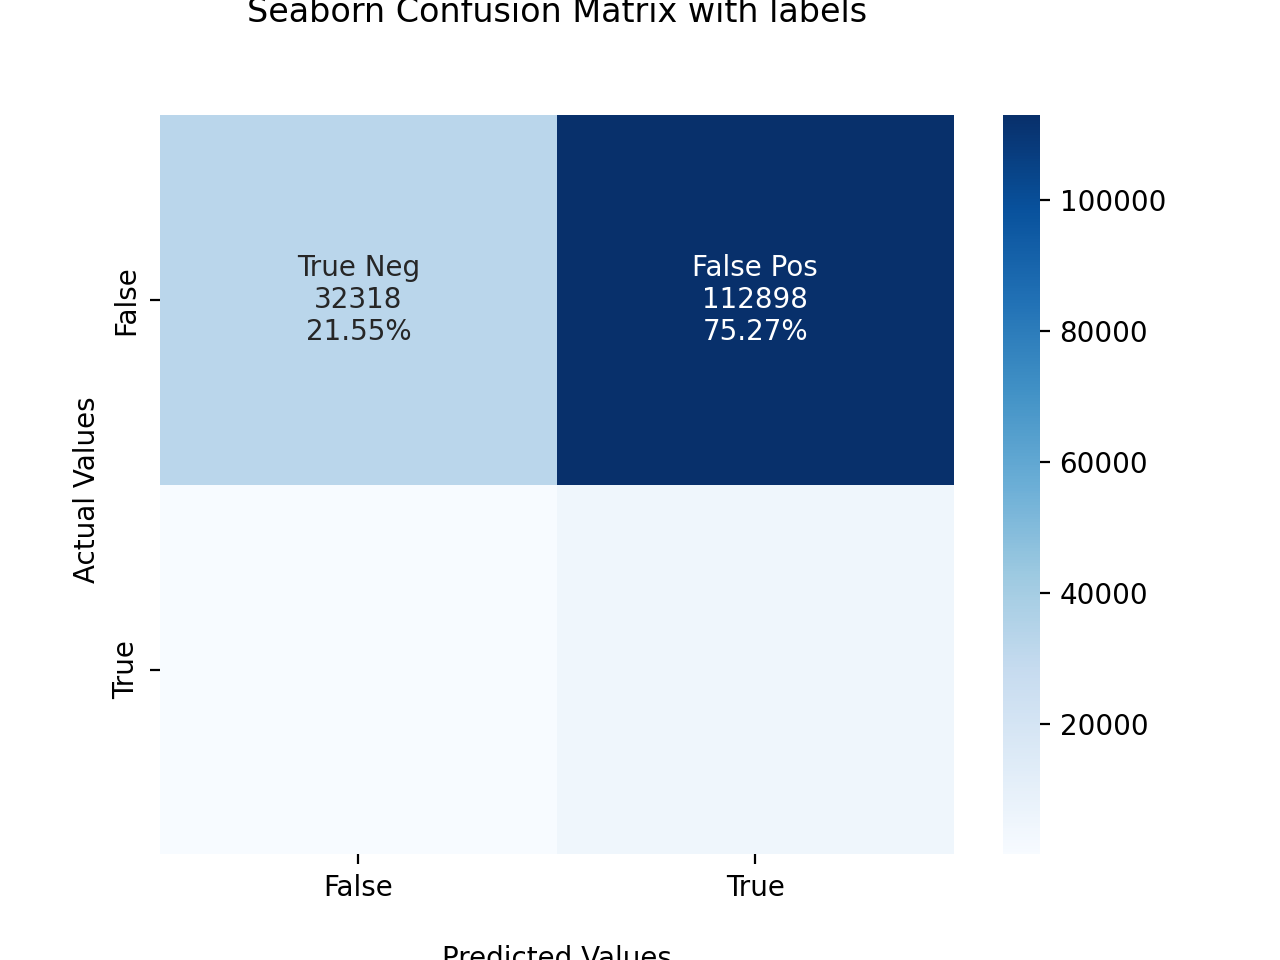

In [106]:
view_conf_matrix(confusion_matrix(t['y_true'], t['y_pred_thr_select_threshold']))

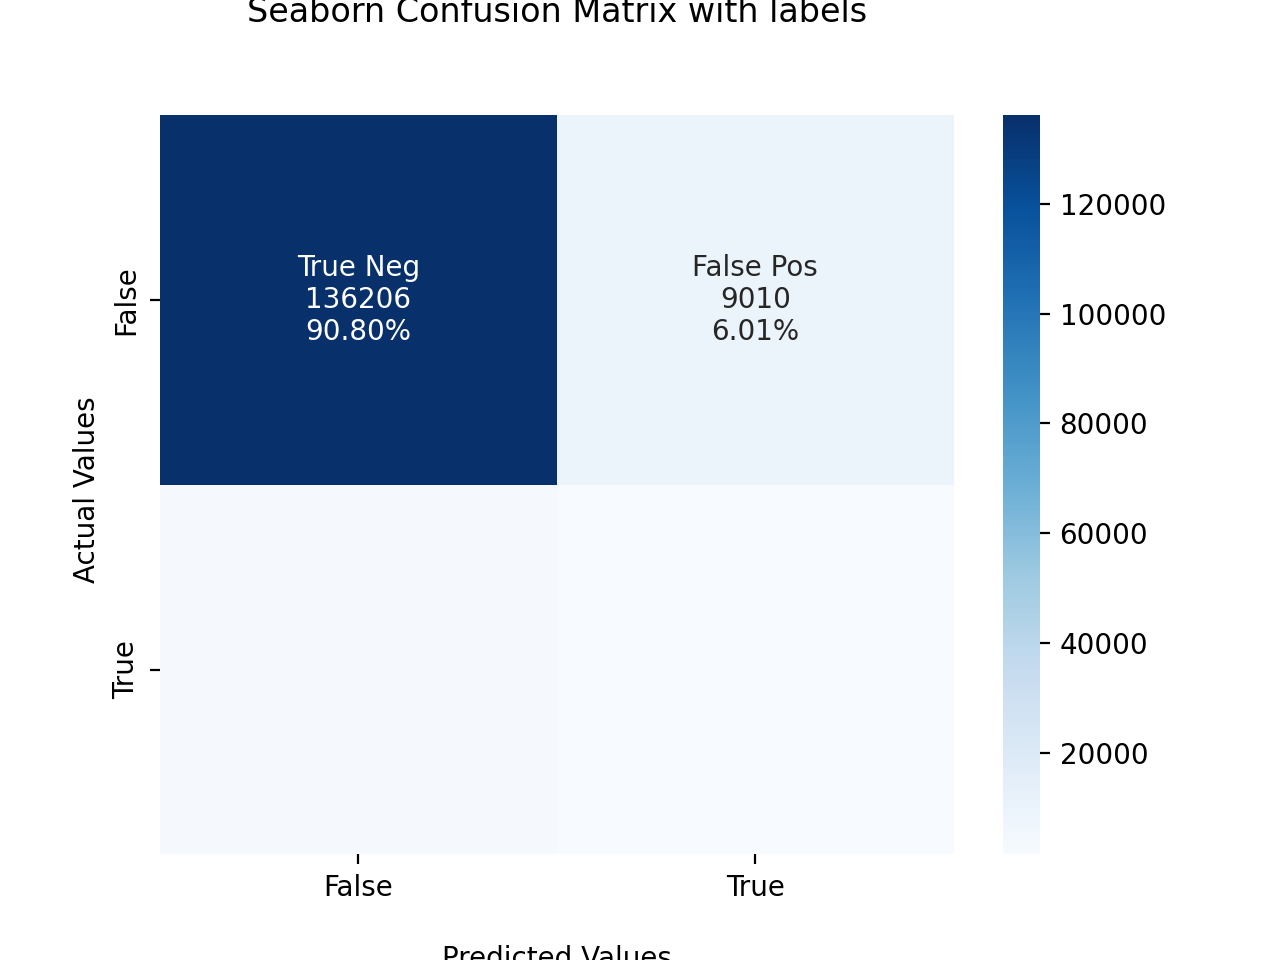

In [107]:
view_conf_matrix(confusion_matrix(t['y_true'], t['y_pred_thr_tune']))

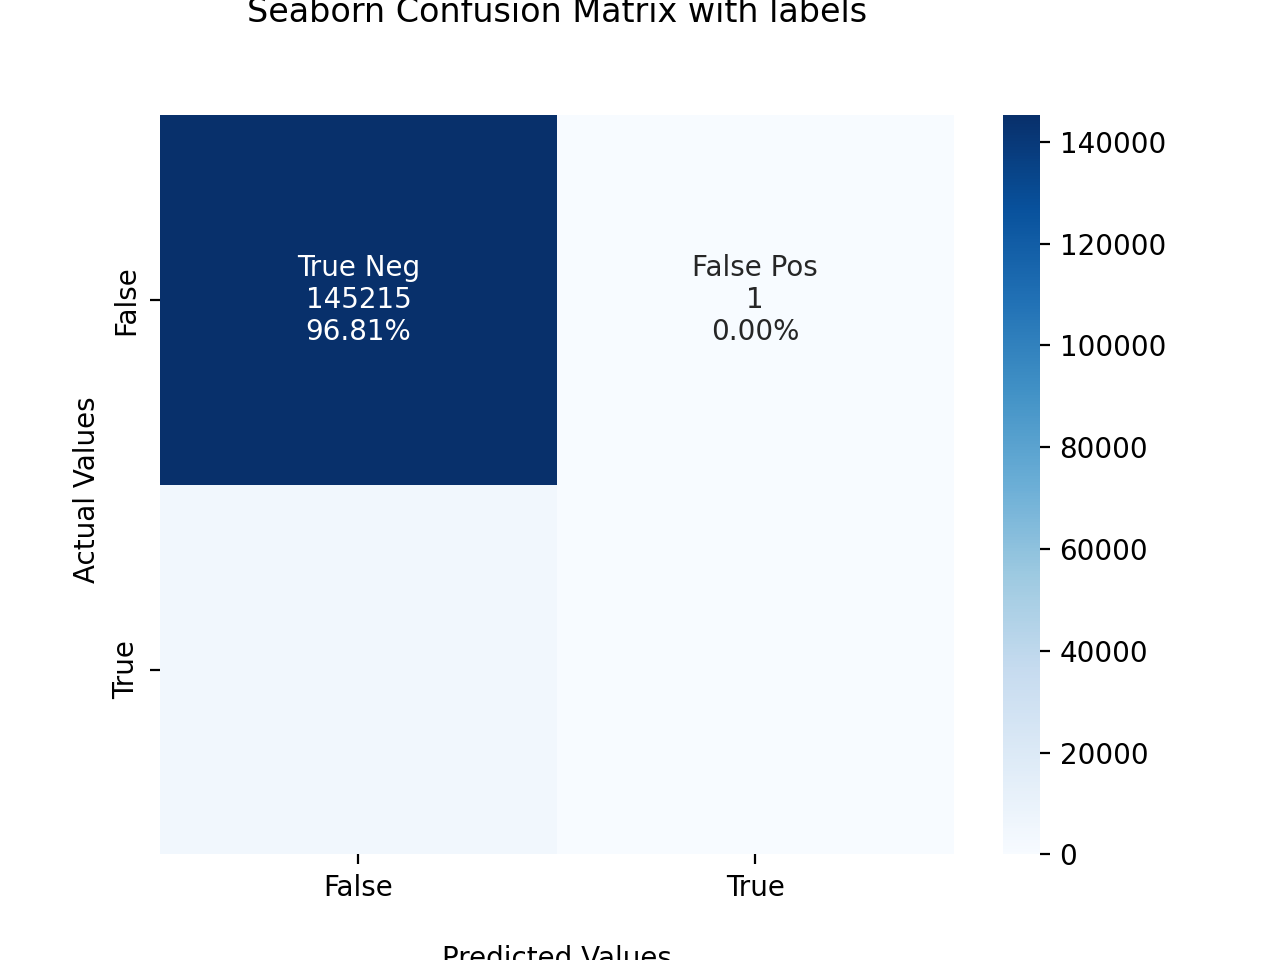

In [108]:
view_conf_matrix(confusion_matrix(t['y_true'], t['y_pred_thr_pr_curve']))

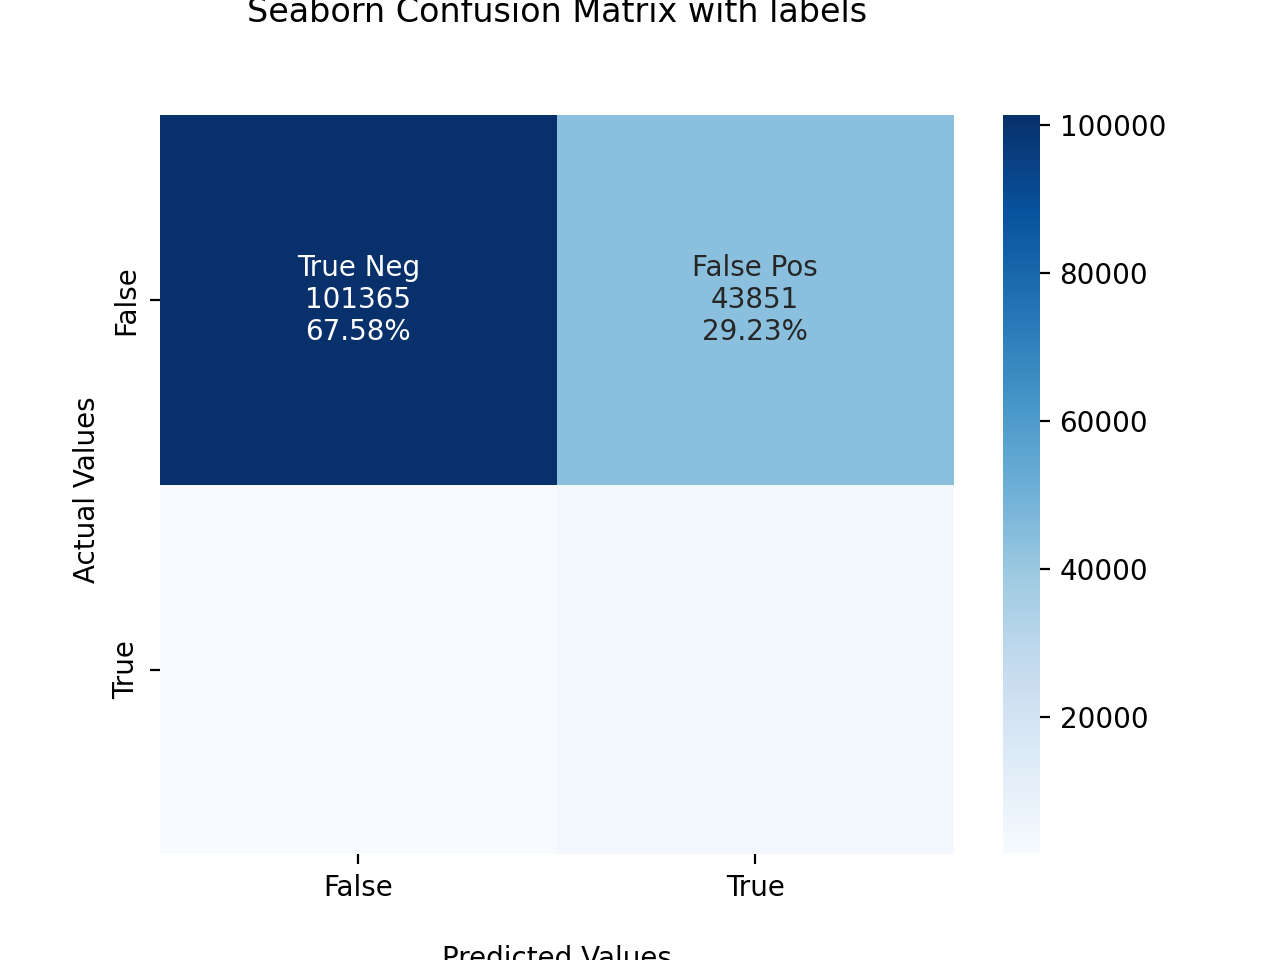

In [109]:
view_conf_matrix(confusion_matrix(t['y_true'], t['y_pred_thr_youdenJ']))

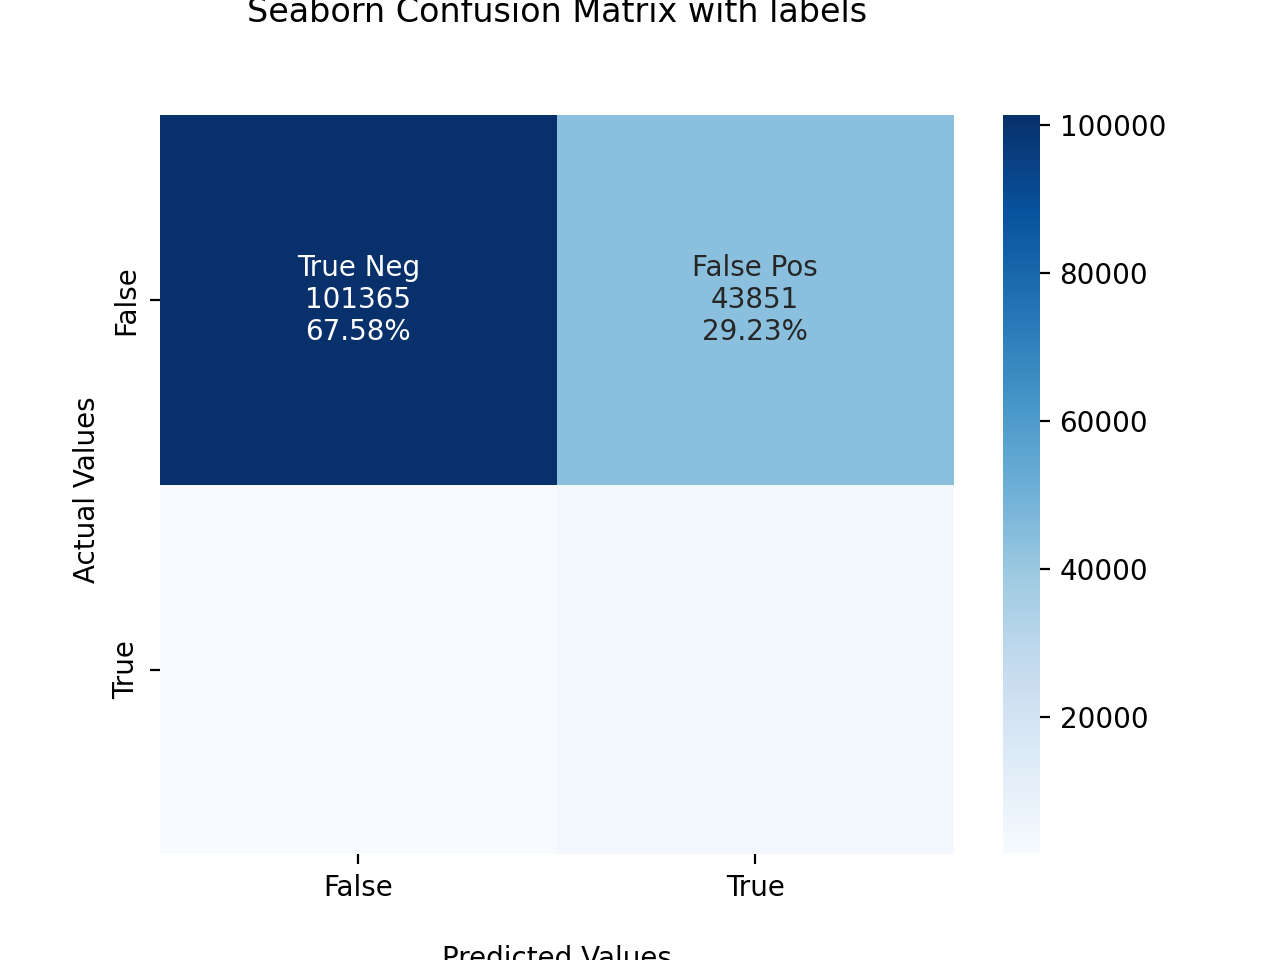

In [110]:
view_conf_matrix(confusion_matrix(t['y_true'], t['y_pred_thr_gmean']))

In [111]:
classification_report_actual = classification_report(t.y_true, t.y_pred_thr_gmean, target_names=['no','yes'])
print( classification_report_actual)

              precision    recall  f1-score   support

          no       0.99      0.70      0.82    145216
         yes       0.07      0.72      0.13      4784

    accuracy                           0.70    150000
   macro avg       0.53      0.71      0.47    150000
weighted avg       0.96      0.70      0.80    150000



# 12. Итог

Для построения итоговой модели будем использовать следующие инструменты:
1. За базовую модель взяли CatboostClassifire из-за возможности использовать GPU, за счет чего вырастает скорость обучения
2. Для определения важности признаков применяем Рекурсивное исключение признаков от Catboost из-за наглядности, 
совместимостью с CatboostClassifire(+скорость) и достаточно высокого ROC AUC.
3. В качестве балансировки таргета используем метод Weghts, который показал лучшее качество и повышения метрики
4. Тюнинг параметров модели по скорости и качеству личшим стал Optuna
5. Для итоговой модели используем ансабль из CatboostClassifire на GPU и CPU, а также Логистическую регресию.
Не смотря на то, что для обучения двух моделей мы использовали CatBoost, на GPU и CPU модели дают разные результаты из-за различия методов обучения. Логистическа регресии показала лучшие результаты по сравнениюс RandomForest и MLP.
6. Для выобра порога принятия решения можно использовать методы G-среднего или Статистику Юдена.
По матрице ошибок видно, использование данного порога дает нам максимальное количество истинно-позитивных при минимальном ложно-негативном количестве. Т.К. для модели важно в первую очередь определить дефолт